# Patterns of Success — Exploring Socio-economic and Demographic Factors in High School SAT Performance

---


### Summary of Findings

#### [Link](#key-findings)

---

## Project Aims

>* The end goal of this study is to compile relevant exam score data along with associated socio-economic and demographic data for general education high schools to identify correlations between variables - can we identify variables that lead to an increase/decrease in the average SAT score?
>
>* Another deliverable this project aims to provide is a ranking system for high schools. Using knowledge acquired from the investigation into correlations, a metric can be devised to evaluate the quality of a school as a means to rank schools from worst-to-best.

Alongside the deliverables, I hope to demonstrate my abilities to construct an end-to-end data analysis project from the ground-up. Thank you for taking the time to read this notebook!


## Project Introduction

In the United States of America, standardized testing of high school students is predominantly conducted through a non-profit company: [College Board](https://about.collegeboard.org). This company has become the de facto standard for standardized testing of junior/senior year high school students as they prepare for college-admissions. 

#### College Board offers two main type of exam: 

>* The **SAT** (Scholastic Aptitude Test) - an exam US high school students take before applying to college/university. Colleges take the test scores into account during admissions, so performing well is important for those wishing to pursue higher education at good institutions. Attaining a high SAT score can also play an important role in acquiring scholarships.
>
>* **AP Exams** (Advanced Placement) - are used extensively in the college admissions process for more academically rigorous institutions, with many of the top college institutions requiring high grades in these exams for a successful application and to award scholarships. 

---

Data from the 2024 annual College Board [report](https://reports.collegeboard.org/media/pdf/2024-total-group-sat-suite-of-assessments-annual-report-ADA.pdf) indicates clear and consistent exam score gaps by race/ethnicity as well as socioeconomic factors (household income, free-reduced price school lunch eligibility and parental education). This report suggest gaps do indeed exist in the modern education landscape. It will be of interest to explore this topic by digging into available data first-hand to see if these patterns can be corroborated and potentially rationalised from analysis conducted here.

Alongside the point above, one of the most controversial issues in the US educational system is the efficacy of this standardized testing practice and whether these exams are truly fair and impartial. 

To investigate these ideas, we set out to assess the strength of correlations between socio-economic, demographic, academic factors that pertain to a school and the corresponding average SAT score for that school. Using the knowledge we acquire, we can then set out to devise a method of evaluating school quality and ranking institutions from worst-to-best. This has potential utility, particularly for councils/government bodies who are responsible for monitorring and supporting education.

## Finding Data

After some research, New York City (NYC) became an optimal candidate for sourcing a dataset from:

* New York City publishes open-access data ([source](data.cityofnewyork.us/browse?category=Education&sortBy=relevance&page=1&pageSize=20), retrieved Sep 2025) in domains we are concerned with. This includes datasets related to SAT results, school demographic data, school survey data, school class size data *etc.*

* New York City is considered one of the most [ethnically diverse](https://en.wikipedia.org/wiki/Demographics_of_New_York_City#cite_note-1) urban centers in the USA. Therefore, using NYC as a sample to represent the student population as a whole is ideal (since there is sufficient representation of all ethnicities/races, which will be an important variable in the analysis).

---

**The following datasets available on NYC Open Data will be cleaned, prepared and merged into a dataset for analysis:**

| Dataset                                                                                                                                   | Description                                                    |
|-------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------|
| [2012 SAT Results](https://data.cityofnewyork.us/Education/2012-SAT-Results/f9bf-2cp4/about_data)                                         | contains records for 2012 College-bound senior's mean SAT scores taken during the 2012 school year |
| [2010 AP Test Results](https://data.cityofnewyork.us/Education/2010-AP-College-Board-School-Level-Results/itfs-ms3e/about_data)           | NYC school level College Board AP results for the 2010  school year|
| [2009-2010 Class Size](https://data.cityofnewyork.us/Education/2009-2010-Class-Size-School-level-Detail/d3ge-anaz/about_data)             | contains average class sizes and size of largest and smallest classes for each school for the 2009-2010 school year, broken out by grade and program type |
| [2005-2015 Graduation Outcomes](https://data.cityofnewyork.us/Education/2005-2015-Graduation-Rates-Public-School/35ey-ieq4/about_data)    |  contains graduation information for students over the 2005-2015 period, defined as those students earning either a local or regents diploma and exclude those earning either a special education (IEP) diploma for GED |
| [2006-2012 Demographics](https://data.cityofnewyork.us/Education/2006-2012-School-Demographics-and-Accountability-S/ihfw-zy9j/about_data) | contains annual school accounts of NYC public school student populations served by grade, special programs, ethnicity, gender and Title I funded programs |
| [2014-2015 High School Directory](https://data.cityofnewyork.us/Education/2014-2015-DOE-High-School-Directory/n3p6-zve2/about_data)       |  a directory of all NYC high schools. Includes location, contact information as well as additional supplementary information. |
| [2011 NYC School Survey](https://data.cityofnewyork.us/Education/2011-NYC-School-Survey/mnz3-dyi8/about_data)                             |  all parents, all teachers, and students in grades 6 - 12 take an annual NYC School Survey. Results are intended to provide insight into a school's learning environment and contribute a measure of diversification that goes beyond test scores on the Progress Report |

---

Although each of these datasets were collected separately (and may not all contain data for all schools in the 2012 SAT Results dataset), they will cover many of the schools (as all of these datasets were collected from NYC schools by the NYC Council). 

Additionally, consideration has also been made to the year that each of the datasets were acquired. Where possible, data collected in the same year as the SAT dataset (2012) will be used. Where there are slight discrepancies in the year of data collection, we can assume there is unlikely to have been a significant deviation in the reported values from year-to-year due to the fact that all of the datasets gathered data from schools around the same period of time.

*Note,* for full details on additional dataset information and to view each dataset's associated data dictionary, refer to the NYC Open Data pages for each dataset (linked above). Where field names need clarification to understand the analysis and conclusions, they will be elaborated upon in the workbook itself.

## Setting up the Notebook and Reading in the Data

In [1]:
import numpy as np
import pandas as pd
pd.options.display.max_columns = 160 # ensure all columns can be rendered in the notebook
pd.options.display.max_rows = 140 # ensure many rows can be rendered in the notebook
import re # regular expressions

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

# apply global rc settings via seaborn so they are active before figures are created
sns.set_theme(rc={
    "grid.linewidth": 1,
    "grid.color": "black",
    "grid.alpha": 0.05,
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "black",
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

csv_files = [
  "ap_2010.csv",
  "class_size.csv",
  "demographics.csv",
  "graduation.csv",
  "hs_directory.csv",
  "sat_results.csv"
  ]

# create a data dictionary to store all dataframes prior to merging
data = {}

# read in all csv files and store in data dictionary
for file in csv_files:
  
  key = file.replace(".csv", "")
  
  df = pd.read_csv(f"schools/{file}")
  
  data[key] = df

In [2]:
data["sat_results"].head()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355,404,363
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383,423,366
2,01M450,EAST SIDE COMMUNITY SCHOOL,70,377,402,370
3,01M458,FORSYTH SATELLITE ACADEMY,7,414,401,359
4,01M509,MARTA VALLE HIGH SCHOOL,44,390,433,384


The `sat_results` dataset contains a DBN field as a unique identifier for each school and includes SAT relevant data (number of test takers from each school and the school average score across each section of the test). 

It will be beneficial to combine the SAT score columns into a total score column for our analysis.


### The SAT

The test consists of three sections: 

* Mathematics (/800)
* English Reading (/800) 
* English Writing (/800)  

making a combined total 2,400 points. 

*Note,* the scoring system has varied over the [history of the SAT](https://en.wikipedia.org/wiki/History_of_the_SAT), but for this project, the total score is based on a 2,400 point total.


In [3]:
data["class_size"] = data["class_size"].drop(columns=["SCHOOL NAME"]) # drop SCHOOL NAME column to avoid duplication of school name columns after merge

data["class_size"].head()

,CSD,BOROUGH,SCHOOL CODE,GRADE,PROGRAM TYPE,CORE SUBJECT (MS CORE and 9-12 ONLY),CORE COURSE (MS CORE and 9-12 ONLY),SERVICE CATEGORY(K-9* ONLY),NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,DATA SOURCE,SCHOOLWIDE PUPIL-TEACHER RATIO
0,1,M,M015,0K,GEN ED,-,-,-,19.0,1.0,19.0,19.0,19.0,ATS,NaN
1,1,M,M015,0K,CTT,-,-,-,21.0,1.0,21.0,21.0,21.0,ATS,NaN
2,1,M,M015,01,GEN ED,-,-,-,17.0,1.0,17.0,17.0,17.0,ATS,NaN
3,1,M,M015,01,CTT,-,-,-,17.0,1.0,17.0,17.0,17.0,ATS,NaN
4,1,M,M015,02,GEN ED,-,-,-,15.0,1.0,15.0,15.0,15.0,ATS,NaN


In [4]:
data["demographics"] = data["demographics"].drop(columns=["Name"]) # drop Name column to avoid duplication of school name columns after merge

data["demographics"].head()

,DBN,schoolyear,fl_percent,frl_percent,total_enrollment,prek,k,grade1,grade2,grade3,grade4,grade5,grade6,grade7,grade8,grade9,grade10,grade11,grade12,ell_num,ell_percent,sped_num,sped_percent,ctt_num,selfcontained_num,asian_num,asian_per,black_num,black_per,hispanic_num,hispanic_per,white_num,white_per,male_num,male_per,female_num,female_per
0,01M015,20052006,89.4,NaN,281,15,36,40,33,38,52,29,38,NaN,NaN,NaN,NaN,NaN,NaN,36.0,12.8,57.0,20.3,25,9,10,3.6,74,26.3,189,67.3,5,1.8,158.0,56.2,123.0,43.8
1,01M015,20062007,89.4,NaN,243,15,29,39,38,34,42,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,15.6,55.0,22.6,19,15,18,7.4,68,28.0,153,63.0,4,1.6,140.0,57.6,103.0,42.4
2,01M015,20072008,89.4,NaN,261,18,43,39,36,38,47,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.0,19.9,60.0,23.0,20,14,16,6.1,77,29.5,157,60.2,7,2.7,143.0,54.8,118.0,45.2
3,01M015,20082009,89.4,NaN,252,17,37,44,32,34,39,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,19.0,62.0,24.6,21,17,16,6.3,75,29.8,149,59.1,7,2.8,149.0,59.1,103.0,40.9
4,01M015,20092010,,96.5,208,16,40,28,32,30,24,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0,19.2,46.0,22.1,14,14,16,7.7,67,32.2,118,56.7,6,2.9,124.0,59.6,84.0,40.4


The associated demographics [data dictionary](https://github.com/Benkly/python-data-analysis-projects/tree/master/usa_sat_exam_scores/data_dictionaries/demographics_2006-2012.csv) provides meaning for the fields listed. 

Some of the important fields requiring clarification include: 

* `ell_num`: Total number of english language learners classes per school

* `ell_percent`: Percentage of english language learner's students per school

* Fields beginning with `sped` relate to the numbers and percentages of special education students for each school

* `fl_percent` and `frl_percent`: Percentage of students with free and free/reduced lunch respectively

* `ctt_num`: The number of students in collaborative teaching classes per school

* `selfcontained_num`: The number of students in self-contained special classes per school

* Fields beginning with an ethnicity followed by _num and _per refer to the numbers and percentages of students with the associated ethnicity per school

This project primarily aims to hone in on students in the general education category of programs, rather than special education (as this makes up the majority of students). Therefore, fields such as `ctt_num`, `selfcontained_num` and `sped` fields will be unnecessary for the analysis.

In [5]:
data["graduation"] = data["graduation"].drop(columns=["School Name"]) # drop Name column to avoid duplication of school name columns after merge

data["graduation"].head()

,Demographic,DBN,Cohort,Total Cohort,Total Grads - n,Total Grads - % of cohort,Total Regents - n,Total Regents - % of cohort,Total Regents - % of grads,Advanced Regents - n,Advanced Regents - % of cohort,Advanced Regents - % of grads,Regents w/o Advanced - n,Regents w/o Advanced - % of cohort,Regents w/o Advanced - % of grads,Local - n,Local - % of cohort,Local - % of grads,Still Enrolled - n,Still Enrolled - % of cohort,Dropped Out - n,Dropped Out - % of cohort
0,Total Cohort,01M292,2003,5,s,s,s,s,s,s,s,s,s,s,s,s,s,s,s,s,s,s
1,Total Cohort,01M292,2004,55,37,67.3%,17,30.9%,45.9%,0,0%,0%,17,30.9%,45.9%,20,36.4%,54.1%,15,27.3%,3,5.5%
2,Total Cohort,01M292,2005,64,43,67.2%,27,42.2%,62.8%,0,0%,0%,27,42.2%,62.8%,16,25%,37.200000000000003%,9,14.1%,9,14.1%
3,Total Cohort,01M292,2006,78,43,55.1%,36,46.2%,83.7%,0,0%,0%,36,46.2%,83.7%,7,9%,16.3%,16,20.5%,11,14.1%
4,Total Cohort,01M292,2006 Aug,78,44,56.4%,37,47.4%,84.1%,0,0%,0%,37,47.4%,84.1%,7,9%,15.9%,15,19.2%,11,14.1%


The `graduation` dataset contains annual graduate data for each school in the dataset. A full summary of the fields can be found in the associated [data dictionary](https://github.com/Benkly/python-data-analysis-projects/tree/master/usa_sat_exam_scores/data_dictionaries/graduation_2005-2006.csv).

* Fields with `Regents` indicate graduates who passed [Regent exams](https://en.wikipedia.org/wiki/New_York_Regents_Examinations). These are *New York specific* standardized tests.

* Fields with `Local` indicate graduates who received local diplomas.

In [6]:
data["hs_directory"] = data["hs_directory"].drop(columns=["school_name"]) # drop Name column to avoid duplication of school name columns after merge

data["hs_directory"].head(3)

,dbn,boro,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,bus,subway,primary_address_line_1,city,state_code,zip,website,total_students,campus_name,school_type,overview_paragraph,program_highlights,language_classes,advancedplacement_courses,online_ap_courses,online_language_courses,extracurricular_activities,psal_sports_boys,psal_sports_girls,psal_sports_coed,school_sports,partner_cbo,partner_hospital,partner_highered,partner_cultural,partner_nonprofit,partner_corporate,partner_financial,partner_other,addtl_info1,addtl_info2,start_time,end_time,se_services,ell_programs,school_accessibility_description,number_programs,priority01,priority02,priority03,priority04,priority05,priority06,priority07,priority08,priority09,priority10,Location 1
0,17K548,Brooklyn,K440,718-230-6250,718-230-6262,9,12,NaN,NaN,"B41, B43, B44-SBS, B45, B48, B49, B69","2, 3, 4, 5, F, S to Botanic Garden ; B, Q to P...",883 Classon Avenue,Brooklyn,NY,11225,Bkmusicntheatre.com,399.0,Prospect Heights Educational Campus,NaN,Brooklyn School for Music & Theatre (BSMT) use...,We offer highly competitive positions in our D...,Spanish,"English Language and Composition, United State...",NaN,NaN,"Variety of clubs: Chess, The Step Team, Fashio...","Baseball, Basketball & JV Basketball, Cross Co...","Basketball, Cross Country, Indoor Track, Outdo...",NaN,NaN,F.Y.R.EZONE (Finding Your Rhythm thru Educatio...,NaN,NaN,"In 2002, Roundabout Theatre was selected by Ne...",One To World‘s Global Classroom connects New Y...,NaN,NaN,NaN,NaN,NaN,8:10 AM,3:00 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to Brooklyn students or residents,Then to New York City residents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"883 Classon Avenue\nBrooklyn, NY 11225\n(40.67..."
1,09X543,Bronx,X400,718-842-0687,718-589-9849,9,12,NaN,NaN,"Bx13, Bx15, Bx17, Bx21, Bx35, Bx4, Bx41, Bx4A,...","2, 5 to Intervale Ave",1110 Boston Road,Bronx,NY,10456,www.hsvd.org,378.0,Morris Educational Campus,NaN,The High School for Violin and Dance (HSVD) is...,Freshmen take both violin and dance; College N...,Spanish,NaN,NaN,NaN,Advancement via Individual Determination (AVID...,"Baseball, Basketball & JV Basketball, Volleyball","Basketball, Softball, Volleyball",NaN,Morris Educational Campus Basketball and Volle...,McGraw Hill - Big Brother Big Sister,NaN,"Hostos Community College, Monroe College, Teac...",Bronx Arts Ensemble,buildOn,Print International,NaN,Bronx Cares,Our students are required to take four years o...,"Student Summer Orientation, Summer Internship ...",8:00 AM,3:00 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to Bronx students or residents who at...,Then to New York City residents who attend an ...,Then to Bronx students or residents,Then to New York City residents,NaN,NaN,NaN,NaN,NaN,NaN,"1110 Boston Road\nBronx, NY 10456\n(40.8276026..."
2,09X327,Bronx,X240,718-294-8111,718-294-8109,6,12,NaN,NaN,"Bx1, Bx11, Bx13, Bx18, Bx2, Bx3, Bx32, Bx35, Bx36","4 to Mt Eden Ave ; B, D to 170th St",1501 Jerome Avenue,Bronx,NY,10452,http://schools.nyc.gov/schoolportals/09/X327,543.0,DOE New Settlement Community Campus,NaN,At the Comprehensive Model School Project (CMS...,"After-school and Saturday Tutoring, Advisory, ...",Spanish,"Biology, Chemistry, United States History",NaN,NaN,"Choir, Gaming, Girls Club, Newspaper, Spanish,...",NaN,NaN,NaN,"As we expand, we plan to offer PSAL sports.",New Settlement Community Center,Montefiore Hospital,NaN,NaN,NaN,NaN,NaN,NaN,Dress Code Required: white or baby blue button...,NaN,8:00 AM,4:00 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to continuing 8th graders,Then to Bronx students or residents who attend...,Then to New York City residents who attend an ...,Then to Bronx students or residents,Then to New York City residents,NaN,NaN,NaN,NaN,NaN,"1501 Jerome Avenue\nBronx, NY 10452\n(40.84241..."


A full summary for the meanings of the fields in the `hs_directory` can be found in the associated [data dictionary](https://github.com/Benkly/python-data-analysis-projects/tree/master/usa_sat_exam_scores/data_dictionaries/hs_directory_2014-2015.csv).

The most notable piece of information this dataset provides is the location data in column `Location 1`. The coordinates for each school can be extracted from this field to investigate geographic trends.

In [7]:
data["ap_2010"] = data["ap_2010"].drop(columns=["SchoolName"]) # drop Name column to avoid duplication of school name columns after merge

data["ap_2010"].head()

,DBN,AP Test Takers,Total Exams Taken,Number of Exams with scores 3 4 or 5
0,01M448,39,49,10
1,01M450,19,21,s
2,01M515,24,26,24
3,01M539,255,377,191
4,02M296,s,s,s


#### AP Exams

Advanced Placement (AP) exams are taken by many high school students before applying to college. These are subject-specific and often delve into first-year undergraduate material for the chosen subject. As a result, they are one of the most advanced and challenging examinations a high school student is able to take. The final grade of an AP exam is on a scale of 1-5 with a 3+ being a passing score. 

Students who are hoping to attend more academically challenging institutions often require good AP scores, so this could provide another avenue to look into for our analysis.

Specifically, we can look the following question: **are AP exam scores are correlated with SAT scores?** 

If so, this could support the idea that students who perform well on exams testing more foundational critical reasoning skills (which is the intended purpose of the SAT) tend to perform better on exams probing higher level, subject-specific content. This is the consensus that high schools, colleges and universities share, with many teachers and professors placing a high value on [SAT scores as a predictor of academic and future career success](https://www.sciencedirect.com/science/article/pii/S0165176525001296).

In [8]:
surveys = [
  "survey_all.txt",
  "survey_d75.txt"
]

survey_dfs = []

# read in survey files and store dataframes in list
for file in surveys:
  
  df = pd.read_csv(f"schools/{file}", delimiter="\t", encoding="windows-1252")
  
  survey_dfs.append(df)
 
# concatenate survey dataframes 
survey = pd.concat(survey_dfs, axis=0)

survey = survey.drop(columns=["schoolname"])

survey.head()

,dbn,bn,d75,studentssurveyed,highschool,schooltype,rr_s,rr_t,rr_p,N_s,N_t,N_p,nr_s,nr_t,nr_p,saf_p_11,com_p_11,eng_p_11,aca_p_11,saf_t_11,com_t_11,eng_t_11,aca_t_11,saf_s_11,com_s_11,eng_s_11,aca_s_11,saf_tot_11,com_tot_11,eng_tot_11,aca_tot_11,p_q2h,p_q7a,p_q7b,p_q7c,p_q7d,p_q8a,p_q8b,p_q8c,p_q8d,p_q8e,p_q8f,p_q2b,p_q2d,p_q2e,p_q2f,p_q2g,p_q3a,p_q3b,p_q4b,p_q4c,p_q11c,p_q2a,p_q2c,p_q3c,p_q6a,p_q6b,p_q11d,p_q11e,p_q5,p_q4a,p_q4d,p_q4e,p_q11a,p_q11b,p_q11f,p_q1,p_q3d,p_q9,p_q10,p_q12aa,p_q12ab,p_q12ac,p_q12ad,p_q12ba,p_q12bb,p_q12bc,p_q12bd,p_q1_1,p_q1_2,...,s_q7d_5,s_q8e_1,s_q8e_2,s_q8e_3,s_q8f_1,s_q8f_2,s_q8f_3,s_q8g_1,s_q8g_2,s_q8g_3,s_q8h_1,s_q8h_2,s_q8h_3,s_q8i_1,s_q8i_2,s_q8i_3,s_q8j_1,s_q8j_2,s_q8j_3,s_q8k_1,s_q8k_2,s_q8k_3,s_q8l_1,s_q8l_2,s_q8l_3,s_q9i_1,s_q9i_2,s_q9i_3,s_q9j_1,s_q9j_2,s_q9j_3,s_q9k_1,s_q9k_2,s_q9k_3,s_q9l_1,s_q9l_2,s_q9l_3,s_q10_1,s_q10_2,s_q10_3,s_q10_4,s_q11a_1,s_q11a_2,s_q11a_3,s_q11a_4,s_q11b_1,s_q11b_2,s_q11b_3,s_q11b_4,s_q11c_1,s_q11c_2,s_q11c_3,s_q11c_4,s_q12d_1,s_q12d_2,s_q12d_3,s_q12d_4,s_q12e_1,s_q12e_2,s_q12e_3,s_q12e_4,s_q12f_1,s_q12f_2,s_q12f_3,s_q12f_4,s_q12g_1,s_q12g_2,s_q12g_3,s_q12g_4,s_q14_1,s_q14_2,s_q14_3,s_q14_4,s_q14_5,s_q14_6,s_q14_7,s_q14_8,s_q14_9,s_q14_10,s_q14_11
0,01M015,M015,0,No,0.0,Elementary School,NaN,88,60,NaN,22.0,90.0,0,25,150,8.5,7.6,7.5,7.8,7.5,7.8,7.6,7.9,NaN,NaN,NaN,NaN,8.0,7.7,7.5,7.9,8.0,8.2,8.3,7.5,7.9,6.8,8.7,9.7,8.7,9.9,9.9,7.7,8.3,7.9,8.1,7.5,7.3,6.7,7.6,7.9,7.5,8.0,7.4,8.7,6.3,6.6,7.6,7.6,7.4,7.8,7.4,NaN,8.3,7.5,7.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01M019,M019,0,No,0.0,Elementary School,NaN,100,60,NaN,34.0,161.0,0,33,269,8.4,7.6,7.6,7.8,8.6,8.5,8.9,9.1,NaN,NaN,NaN,NaN,8.5,8.1,8.2,8.4,7.7,7.9,8.0,7.3,7.7,6.5,8.8,9.4,8.7,10.0,9.9,7.5,8.2,7.9,8.0,7.2,7.0,6.9,8.0,8.4,7.4,7.6,7.1,9.0,6.4,6.5,7.6,7.8,8.6,7.7,7.8,NaN,8.3,7.6,7.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01M020,M020,0,No,0.0,Elementary School,NaN,88,73,NaN,42.0,367.0,0,48,505,8.9,8.3,8.3,8.6,7.6,6.3,6.8,7.5,NaN,NaN,NaN,NaN,8.2,7.3,7.5,8.0,8.1,8.8,8.9,8.5,8.4,7.6,9.2,9.4,9.2,9.8,9.7,8.4,8.8,8.5,8.3,8.0,7.6,7.3,8.6,8.7,8.4,8.8,8.2,8.8,7.9,6.8,8.5,8.5,8.7,8.6,8.5,NaN,8.9,8.4,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01M034,M034,0,Yes,0.0,Elementary / Middle School,89.0,73,50,145.0,29.0,151.0,163,40,301,8.8,8.2,8.0,8.5,7.0,6.2,6.8,7.8,6.2,5.9,6.5,7.4,7.3,6.7,7.1,7.9,8.1,8.5,8.8,8.2,8.3,7.3,9.2,9.4,9.1,9.8,9.7,8.3,8.7,8.3,8.1,7.6,7.6,7.5,8.6,8.6,8.4,8.5,8.1,8.8,7.3,6.8,8.2,8.3,8.0,8.7,8.3,NaN,8.8,8.3,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01M063,M063,0,No,0.0,Elementary School,NaN,100,60,NaN,23.0,90.0,0,23,151,8.7,7.9,8.1,7.9,8.4,7.3,7.8,8.1,NaN

The survey data contains almost 3,000 columns, the majority of which are completely irrelevant for this investigation. 

The data dictionary for these surveys are publically available on the [NYC Open Data](https://data.cityofnewyork.us/Education/2011-NYC-School-Survey/mnz3-dyi8/about_data) and is provided directly in [this repo](https://github.com/Benkly/python-data-analysis-projects/tree/master/usa_sat_exam_scores/data_dictionaries/nyc_school_survey_2011.csv).

The survey fields listed in the code block below could have some relevance to our analysis, so will be kept in the filtered survey dataframe:

* `DBN` - School unique identifier
* `rr_s` - Student Response Rate
* `rr_t` - Teacher Response Rate
* `rr_p` - Parent/Carer Response Rate
* `N_s` - Number of Student Respondants
* `N_t` - Number of Teacher Respondants
* `N_p` - Number of Parent/Carer Respondants

* Fields beginning with `saf` refer to the Safety and Respect Score for the school. For instance, `saf_p_11` refers to the derived safety score from *parent* (p) survey responses in 2011.

* Fields beginning with `com` refer to the Communication Score for the school

* Fields beginning with `eng` refer to the Engagement Score for the school

* Fields beginning with `aca` refer to the Academic Expectations Score for the school


In [9]:
# create a copy of the survey dataframe
survey = survey.copy()

# rename the "dbn" column to "DBN" for consistency
survey["DBN"] = survey["dbn"]

# filter out columns that are not needed by keeping only those listed and store resulting survey dataframe to the data dictionary
survey_fields = [
    "DBN", 
    "rr_s", 
    "rr_t", 
    "rr_p", 
    "N_s", 
    "N_t", 
    "N_p", 
    "saf_p_11", 
    "com_p_11", 
    "eng_p_11", 
    "aca_p_11", 
    "saf_t_11", 
    "com_t_11", 
    "eng_t_11", 
    "aca_t_11", 
    "saf_s_11", 
    "com_s_11", 
    "eng_s_11", 
    "aca_s_11", 
    "saf_tot_11", 
    "com_tot_11", 
    "eng_tot_11", 
    "aca_tot_11"
]

survey = survey[survey_fields]

data["survey"] = survey

In [10]:
data["survey"].head()

,DBN,rr_s,rr_t,rr_p,N_s,N_t,N_p,saf_p_11,com_p_11,eng_p_11,aca_p_11,saf_t_11,com_t_11,eng_t_11,aca_t_11,saf_s_11,com_s_11,eng_s_11,aca_s_11,saf_tot_11,com_tot_11,eng_tot_11,aca_tot_11
0,01M015,NaN,88,60,NaN,22.0,90.0,8.5,7.6,7.5,7.8,7.5,7.8,7.6,7.9,NaN,NaN,NaN,NaN,8.0,7.7,7.5,7.9
1,01M019,NaN,100,60,NaN,34.0,161.0,8.4,7.6,7.6,7.8,8.6,8.5,8.9,9.1,NaN,NaN,NaN,NaN,8.5,8.1,8.2,8.4
2,01M020,NaN,88,73,NaN,42.0,367.0,8.9,8.3,8.3,8.6,7.6,6.3,6.8,7.5,NaN,NaN,NaN,NaN,8.2,7.3,7.5,8.0
3,01M034,89.0,73,50,145.0,29.0,151.0,8.8,8.2,8.0,8.5,7.0,6.2,6.8,7.8,6.2,5.9,6.5,7.4,7.3,6.7,7.1,7.9
4,01M063,NaN,100,60,NaN,23.0,90.0,8.7,7.9,8.1,7.9,8.4,7.3,7.8,8.1,NaN,NaN,NaN,NaN,8.5,7.6,7.9,8.0


In [11]:
data["survey"].shape

(1702, 23)

This has filtered down to just 23 columns which is far more managable.

---

#### Reviewing each of the datasets, we must think about how to combine them for our eventual analysis:

* Each school is issued an identification code (the **District Borough Number, DBN**) which can be used as a primary key.

* For this to be the case, we must ensure there is only **one** instance of each unique DBN in each dataset (and that the "DBN" column name is consistent across all datasets). Failing to address this will cause problems when trying to merge the datasets on the DBN values.

## Preparing and Condensing each Dataset 

Prior to merging all of the dataframes, further cleaning and condensing must be conducted to ensure the `DBN` field is in a state that will support joining (there must only be one instance of a DBN in each dataset and the DBN column name must be idential between all datasets).

There are some datasets that require more attention than others. For instance, the `class_size` dataset does not contain a `DBN` field. It does however contain the information in each record necessary to construct the DBN.

The DBN is a unique identifier for all NYC public schools (as described by the following [source](https://teachnyc.zendesk.com/hc/en-us/articles/360053601831-What-is-a-DBN-District-Borough-Number)). 

A DBN uses the format: `##-A-###`

* The first two characters represent the School District Number (`CSD`). This is padded such that it is two digits - *e.g.,* 01, 07, 11, 47, 99. 

 * The third character is a one letter code corresponding to the borough

      | Code    | Borough               |
      |---------|-----------------------|
      | K       | Brooklyn              |
      | X       | Bronx                 |
      | Q       | Queens                |
      | M       | Manhattan             |
      | R       | Staten Island         |

---

* The final three characters are unique numbers assigned to each school (the School Number).

#### Adding and Modifying DBN Fields

In [12]:
# create a copy of the "dbn" column in the hs_directory dataframe and store it as "DBN"
data["hs_directory"]["DBN"] = data["hs_directory"]["dbn"]

# function which adds leading zeros to the "CSD" column
def pad_csd(csd):
    
    csd = str(csd)
    
    if len(csd) < 2:
        return csd.zfill(2) # return a string of length two padded with ASCII "0" characters
    
    else:
        return csd
        
data["class_size"]["padded_csd"] = data["class_size"]["CSD"].apply(pad_csd)

data["class_size"]["DBN"] = data["class_size"]["padded_csd"] + data["class_size"]["SCHOOL CODE"]

data["class_size"].head()

,CSD,BOROUGH,SCHOOL CODE,GRADE,PROGRAM TYPE,CORE SUBJECT (MS CORE and 9-12 ONLY),CORE COURSE (MS CORE and 9-12 ONLY),SERVICE CATEGORY(K-9* ONLY),NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,DATA SOURCE,SCHOOLWIDE PUPIL-TEACHER RATIO,padded_csd,DBN
0,1,M,M015,0K,GEN ED,-,-,-,19.0,1.0,19.0,19.0,19.0,ATS,NaN,01,01M015
1,1,M,M015,0K,CTT,-,-,-,21.0,1.0,21.0,21.0,21.0,ATS,NaN,01,01M015
2,1,M,M015,01,GEN ED,-,-,-,17.0,1.0,17.0,17.0,17.0,ATS,NaN,01,01M015
3,1,M,M015,01,CTT,-,-,-,17.0,1.0,17.0,17.0,17.0,ATS,NaN,01,01M015
4,1,M,M015,02,GEN ED,-,-,-,15.0,1.0,15.0,15.0,15.0,ATS,NaN,01,01M015


Each dataframe now has a `DBN` field, though further work is required to reduce this down so that only one instance of each DBN is featured in each dataset. Prior to addressing this, some additional fields can be added to the existing dataframes to ease the analysis process later.

#### Combining the SAT scores

In [13]:
cols = ["SAT Math Avg. Score", "SAT Critical Reading Avg. Score", "SAT Writing Avg. Score"]

for col in cols:
    
    data["sat_results"][col] = pd.to_numeric(data["sat_results"][col], errors="coerce") # errors="coerce" converts any non-numeric values to NaN
    
data["sat_results"]["avg_sat_score"] = data["sat_results"][cols[0]] + data["sat_results"][cols[1]] + data["sat_results"][cols[2]]
    
data["sat_results"].head()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,avg_sat_score
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355.0,404.0,363.0,1122.0
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383.0,423.0,366.0,1172.0
2,01M450,EAST SIDE COMMUNITY SCHOOL,70,377.0,402.0,370.0,1149.0
3,01M458,FORSYTH SATELLITE ACADEMY,7,414.0,401.0,359.0,1174.0
4,01M509,MARTA VALLE HIGH SCHOOL,44,390.0,433.0,384.0,1207.0


#### Parsing Latitude and Longitude to Map School Locations

The `Location 1` field in the `hs_directory` dataframe contains geographic coordinates of each school stored in a string. A combination of RegEx and string methods can be used to extract these coordinates which can be assigned to new columns:

In [14]:
def find_latitude(loc):
    
    coords = re.findall(r"\(.+, .+\)", loc)
    
    lat = coords[0].split(",")[0].replace("(", "")
    
    return lat
    
def find_longitude(loc):
    
    coords = re.findall(r"\(.+, .+\)", loc)
    
    lon = coords[0].split(",")[1].replace(")", "")
    
    return lon

data["hs_directory"]["lat"] = data["hs_directory"]["Location 1"].apply(find_latitude)

data["hs_directory"]["lon"] = data["hs_directory"]["Location 1"].apply(find_longitude)

data["hs_directory"]["lat"] = pd.to_numeric(data["hs_directory"]["lat"], errors="coerce") # errors="coerce" converts any non-numeric values to NaN

data["hs_directory"]["lon"] = pd.to_numeric(data["hs_directory"]["lon"], errors="coerce")

data["hs_directory"].head(2)

,dbn,boro,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,bus,subway,primary_address_line_1,city,state_code,zip,website,total_students,campus_name,school_type,overview_paragraph,program_highlights,language_classes,advancedplacement_courses,online_ap_courses,online_language_courses,extracurricular_activities,psal_sports_boys,psal_sports_girls,psal_sports_coed,school_sports,partner_cbo,partner_hospital,partner_highered,partner_cultural,partner_nonprofit,partner_corporate,partner_financial,partner_other,addtl_info1,addtl_info2,start_time,end_time,se_services,ell_programs,school_accessibility_description,number_programs,priority01,priority02,priority03,priority04,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,DBN,lat,lon
0,17K548,Brooklyn,K440,718-230-6250,718-230-6262,9,12,NaN,NaN,"B41, B43, B44-SBS, B45, B48, B49, B69","2, 3, 4, 5, F, S to Botanic Garden ; B, Q to P...",883 Classon Avenue,Brooklyn,NY,11225,Bkmusicntheatre.com,399.0,Prospect Heights Educational Campus,NaN,Brooklyn School for Music & Theatre (BSMT) use...,We offer highly competitive positions in our D...,Spanish,"English Language and Composition, United State...",NaN,NaN,"Variety of clubs: Chess, The Step Team, Fashio...","Baseball, Basketball & JV Basketball, Cross Co...","Basketball, Cross Country, Indoor Track, Outdo...",NaN,NaN,F.Y.R.EZONE (Finding Your Rhythm thru Educatio...,NaN,NaN,"In 2002, Roundabout Theatre was selected by Ne...",One To World‘s Global Classroom connects New Y...,NaN,NaN,NaN,NaN,NaN,8:10 AM,3:00 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to Brooklyn students or residents,Then to New York City residents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"883 Classon Avenue\nBrooklyn, NY 11225\n(40.67...",17K548,40.670299,-73.961648
1,09X543,Bronx,X400,718-842-0687,718-589-9849,9,12,NaN,NaN,"Bx13, Bx15, Bx17, Bx21, Bx35, Bx4, Bx41, Bx4A,...","2, 5 to Intervale Ave",1110 Boston Road,Bronx,NY,10456,www.hsvd.org,378.0,Morris Educational Campus,NaN,The High School for Violin and Dance (HSVD) is...,Freshmen take both violin and dance; College N...,Spanish,NaN,NaN,NaN,Advancement via Individual Determination (AVID...,"Baseball, Basketball & JV Basketball, Volleyball","Basketball, Softball, Volleyball",NaN,Morris Educational Campus Basketball and Volle...,McGraw Hill - Big Brother Big Sister,NaN,"Hostos Community College, Monroe College, Teac...",Bronx Arts Ensemble,buildOn,Print International,NaN,Bronx Cares,Our students are required to take four years o...,"Student Summer Orientation, Summer Internship ...",8:00 AM,3:00 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to Bronx students or residents who at...,Then to New York City residents who attend an ...,Then to Bronx students or residents,Then to New York City residents,NaN,NaN,NaN,NaN,NaN,NaN,"1110 Boston Road\nBronx, NY 10456\n(40.8276026...",09X543,40.827603,-73.904475


*Note,* a copy of the `dbn` field has been assigned to a column named `DBN`. The original `dbn` field will not be used when merging.

#### Condensing the `class_size` Dataset

After creating some additional useful fields, we can turn to condensing down each of the datasets such that only once instance of each unique `DBN` value appears.

For the `class_size` dataset, the same school has many entries due to the fact that all classes being offered by that school are recorded. We must first filter the records such that only `GEN ED` classes covering grades `09-12` are included. This is most relevant to our investigation and will drastically reduce the number of instances of the same `DBN` value appearing.

In [15]:
class_size = data["class_size"]

class_size = class_size[(class_size["GRADE "] == "09-12") & (class_size["PROGRAM TYPE"] == "GEN ED")]

class_size.head(3)

,CSD,BOROUGH,SCHOOL CODE,GRADE,PROGRAM TYPE,CORE SUBJECT (MS CORE and 9-12 ONLY),CORE COURSE (MS CORE and 9-12 ONLY),SERVICE CATEGORY(K-9* ONLY),NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,DATA SOURCE,SCHOOLWIDE PUPIL-TEACHER RATIO,padded_csd,DBN
225,1,M,M292,09-12,GEN ED,ENGLISH,English 9,-,63.0,3.0,21.0,19.0,25.0,STARS,NaN,01,01M292
226,1,M,M292,09-12,GEN ED,ENGLISH,English 10,-,79.0,3.0,26.3,24.0,31.0,STARS,NaN,01,01M292
227,1,M,M292,09-12,GEN ED,ENGLISH,English 11,-,38.0,2.0,19.0,16.0,22.0,STARS,NaN,01,01M292


This has not completely solved the issue, there are still many classes from the same school that meet those filtering criteria. Therefore, we can aggregate the remaining records by grouping by the `DBN` column.

In [16]:
grouped = class_size.groupby("DBN")

class_size = grouped.agg("mean", numeric_only=True)

class_size.reset_index(inplace=True) # reset index to make DBN a column

data["class_size"] = class_size

data["class_size"].head()

,DBN,CSD,NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,SCHOOLWIDE PUPIL-TEACHER RATIO
0,01M292,1.0,88.0000,4.000000,22.564286,18.50,26.571429,NaN
1,01M332,1.0,46.0000,2.000000,22.000000,21.00,23.500000,NaN
2,01M378,1.0,33.0000,1.000000,33.000000,33.00,33.000000,NaN
3,01M448,1.0,105.6875,4.750000,22.231250,18.25,27.062500,NaN
4,01M450,1.0,57.6000,2.733333,21.200000,19.40,22.866667,NaN


This has solved the problem. We now have `DBN` acting as a primary key for this dataset.

#### Condensing the `demographics` Dataset

This dataset contains multiple entries from the same school due to the `schoolyear` field. We can simply filter the dataset to retrieve just the most recent demographics data (for the 2011-2012 year). This aligns with the year of the `sat_results` dataset too, making this an ideal selection.

In [17]:
demographics = data["demographics"]

demographics = demographics[demographics["schoolyear"] == 20112012]

data["demographics"] = demographics

data["demographics"].head()

,DBN,schoolyear,fl_percent,frl_percent,total_enrollment,prek,k,grade1,grade2,grade3,grade4,grade5,grade6,grade7,grade8,grade9,grade10,grade11,grade12,ell_num,ell_percent,sped_num,sped_percent,ctt_num,selfcontained_num,asian_num,asian_per,black_num,black_per,hispanic_num,hispanic_per,white_num,white_per,male_num,male_per,female_num,female_per
6,01M015,20112012,NaN,89.4,189,13,31,35,28,25,28,29,,,,,,,,20.0,10.6,40.0,21.2,23,7,12,6.3,63,33.3,109,57.7,4,2.1,97.0,51.3,92.0,48.7
13,01M019,20112012,NaN,61.5,328,32,46,52,54,52,46,46,,,,,,,,33.0,10.1,59.0,18.0,16,16,51,15.5,81,24.7,158,48.2,28,8.5,147.0,44.8,181.0,55.2
20,01M020,20112012,NaN,92.5,626,52,102,121,87,88,85,91,,,,,,,,128.0,20.4,97.0,15.5,49,31,190,30.4,55,8.8,357,57.0,16,2.6,330.0,52.7,296.0,47.3
27,01M034,20112012,NaN,99.7,401,14,34,38,36,45,28,40,55,55,56,,,,,34.0,8.5,106.0,26.4,59,16,22,5.5,90,22.4,275,68.6,8,2.0,204.0,50.9,197.0,49.1
35,01M063,20112012,NaN,78.9,176,18,20,30,21,31,26,30,,,,,,,,6.0,3.4,45.0,25.6,34,4,9,5.1,41,23.3,110,62.5,15,8.5,97.0,55.1,79.0,44.9


#### Condensing the `graduation` Dataset

The `demographic` and `cohort` fields are preventing `DBN` from being unique in the `graduation` dataset. To address this, we can select the most recent set of **full** cohort data (Cohort: "2006", demographic: "Total Cohort") 

In [18]:
graduation = data["graduation"]

graduation = graduation[(graduation["Cohort"] == "2006") & (graduation["Demographic"] == "Total Cohort")]

data["graduation"] = graduation

data["graduation"].head(3)

,Demographic,DBN,Cohort,Total Cohort,Total Grads - n,Total Grads - % of cohort,Total Regents - n,Total Regents - % of cohort,Total Regents - % of grads,Advanced Regents - n,Advanced Regents - % of cohort,Advanced Regents - % of grads,Regents w/o Advanced - n,Regents w/o Advanced - % of cohort,Regents w/o Advanced - % of grads,Local - n,Local - % of cohort,Local - % of grads,Still Enrolled - n,Still Enrolled - % of cohort,Dropped Out - n,Dropped Out - % of cohort
3,Total Cohort,01M292,2006,78,43,55.1%,36,46.2%,83.7%,0,0%,0%,36,46.2%,83.7%,7,9%,16.3%,16,20.5%,11,14.1%
10,Total Cohort,01M448,2006,124,53,42.7%,42,33.9%,79.2%,8,6.5%,15.1%,34,27.4%,64.2%,11,8.9%,20.8%,46,37.1%,20,16.100000000000001%
17,Total Cohort,01M450,2006,90,70,77.8%,67,74.400000000000006%,95.7%,0,0%,0%,67,74.400000000000006%,95.7%,3,3.3%,4.3%,15,16.7%,5,5.6%


#### Converting AP Test Scores

The final preparation step before merging the datasets is to convert the AP test score data to a numeric datatype.

**Why are we interested in the AP Test Scores?**

>Advanced Placement (AP) exams are taken by many high school students before applying to college, with the final grade of an AP exam is on a scale of 1-5 (3+ being a passing score). 
>
>Students who are hoping to attend more academically challenging institutions often require good AP scores, so this could provide another avenue to look into for our analysis: **are AP exam scores correlated with SAT scores?**

In [19]:
ap_2010 = data["ap_2010"]

cols = ['AP Test Takers ', 'Total Exams Taken', 'Number of Exams with scores 3 4 or 5']

for col in cols:
  
    print(f"old: {ap_2010[col].dtype}")
    
    ap_2010[col] = pd.to_numeric(ap_2010[col], errors="coerce")
    
    print(f"new: {ap_2010[col].dtype}")

old: object
new: float64
old: object
new: float64
old: object
new: float64


## Merging the Datasets

**Choosing a merging strategy**

---

We are using the “DBN” as the primary key to allow us to merge rows together from across the datasets. There may be values that exist in one dataset, but not another (partly because some data was gathered from different years or it may be a result of inconsistencies/human errors). As a result, we may not find matches for the DBN value in the sat_results dataset in some or all of the other datasets.

To conduct the merge, we can first merge one dataset with another, continuing until all datasets have been combined. 

**Considerations:**

*	The merge strategy we pick will affect the number of rows we end up with, as well as the number of missing values.

* Since we are primarily concerned with correlations of variables with SAT scores, our merging process should ideally preserve as many SAT score values as possible. This means we should perform a LEFT join with the `sat_results` dataset on the left. 

* We also want to minimize null values that result from the merging process, so different joins may be appropriate at each stage.

In [20]:
data["sat_results"]["DBN"].shape[0]

478

There are 478 schools featured in the SAT results dataset (we want to preserve as much of this data as possible).

In [21]:
for df in data:
  
  print(f"{df}: {data[df]['DBN'].shape[0]}")

ap_2010: 258
class_size: 583
demographics: 1509
graduation: 405
hs_directory: 435
sat_results: 478
survey: 1702


The `ap_2010` and `graduation` datasets have the fewest number of schools featured in the dataset. It makes the most sense to perform a left join with the `sat_results` dataset on the left such that we do not drop any of the sat scores.

In [22]:
combined = data["sat_results"]

combined = combined.merge(data["ap_2010"], how="left", on="DBN")

combined = combined.merge(data["graduation"], how="left", on="DBN")

combined["DBN"].shape[0]

479

The remaining datasets to combine include: `class_size`, `demographics`, `hs_directory` and `survey`.

Since these datasets contain information that is more valuable for our analysis (and also have more schools featured in them), an INNER join is most appropriate. 

The merge order follows: `class_size` --> `demographics` --> `survey`  --> `hs_directory`. Generally, the datasets with more schools featured are inner joined first, before moving to the datasets with fewer.

In [23]:
combined = combined.merge(data["class_size"], how="inner", on="DBN")

combined = combined.merge(data["demographics"], how="inner", on="DBN")

combined = combined.merge(data["survey"], how="inner", on="DBN")

combined = combined.merge(data["hs_directory"], how="inner", on="DBN")

combined["DBN"].shape[0]

363

116 rows were lost as a result of the merging process (116 schools from the SAT dataset did not have all of the required data from the four above).

In [24]:
combined.head(3)

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,avg_sat_score,AP Test Takers,Total Exams Taken,Number of Exams with scores 3 4 or 5,Demographic,Cohort,Total Cohort,Total Grads - n,Total Grads - % of cohort,Total Regents - n,Total Regents - % of cohort,Total Regents - % of grads,Advanced Regents - n,Advanced Regents - % of cohort,Advanced Regents - % of grads,Regents w/o Advanced - n,Regents w/o Advanced - % of cohort,Regents w/o Advanced - % of grads,Local - n,Local - % of cohort,Local - % of grads,Still Enrolled - n,Still Enrolled - % of cohort,Dropped Out - n,Dropped Out - % of cohort,CSD,NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,SCHOOLWIDE PUPIL-TEACHER RATIO,schoolyear,fl_percent,frl_percent,total_enrollment,prek,k,grade1,grade2,grade3,grade4,grade5,grade6,grade7,grade8,grade9,grade10,grade11,grade12,ell_num,ell_percent,sped_num,sped_percent,ctt_num,selfcontained_num,asian_num,asian_per,black_num,black_per,hispanic_num,hispanic_per,white_num,white_per,male_num,male_per,female_num,female_per,rr_s,rr_t,rr_p,N_s,N_t,N_p,saf_p_11,com_p_11,eng_p_11,aca_p_11,saf_t_11,com_t_11,eng_t_11,aca_t_11,saf_s_11,com_s_11,eng_s_11,aca_s_11,saf_tot_11,com_tot_11,eng_tot_11,aca_tot_11,dbn,boro,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,bus,subway,primary_address_line_1,city,state_code,zip,website,total_students,campus_name,school_type,overview_paragraph,program_highlights,language_classes,advancedplacement_courses,online_ap_courses,online_language_courses,extracurricular_activities,psal_sports_boys,psal_sports_girls,psal_sports_coed,school_sports,partner_cbo,partner_hospital,partner_highered,partner_cultural,partner_nonprofit,partner_corporate,partner_financial,partner_other,addtl_info1,addtl_info2,start_time,end_time,se_services,ell_programs,school_accessibility_description,number_programs,priority01,priority02,priority03,priority04,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,lat,lon
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355.0,404.0,363.0,1122.0,NaN,NaN,NaN,Total Cohort,2006,78.0,43,55.1%,36,46.2%,83.7%,0,0%,0%,36,46.2%,83.7%,7,9%,16.3%,16,20.5%,11,14.1%,1.0,88.0000,4.000000,22.564286,18.50,26.571429,NaN,20112012,NaN,88.6,422,,,,,,,,32,33,50,98,79,80,50,94.0,22.3,105.0,24.9,34,35,59,14.0,123,29.1,227,53.8,7,1.7,259.0,61.4,163.0,38.6,89.0,70,39,379.0,26.0,151.0,7.8,7.7,7.4,7.6,6.3,5.3,6.1,6.5,6.0,5.6,6.1,6.7,6.7,6.2,6.6,7.0,01M292,Manhattan,M056,212-406-9411,212-406-9417,6,12,NaN,NaN,"B39, M14A, M14D, M15, M15-SBS, M21, M22, M9","B, D to Grand St ; F to East Broadway ; J, M, ...",220 Henry Street,New York,NY,10002,http://schools.nyc.gov/schoolportals/01/M292,323.0,NaN,NaN,Henry Street School for International Studies ...,"Global/International Studies in core subjects,...","Chinese (Mandarin), Spanish",Psychology,"Chinese Language and Culture, Spanish Literatu...","Chinese (Mandarin), Spanish","Math through Card Play; Art, Poetry/Spoken Wor...",Basketball,Softball,Soccer,"Boxing, Track, CHAMPS, Tennis, Flag Football, ...",The Henry Street Settlement; Asia Society; Ame...,Gouverneur Hospital (Turning Points),New York University,Asia Society,Heart of America Foundation,NaN,NaN,United Nations,NaN,NaN,8:30 AM,3:30 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to continuing 8th graders,Then to Manhattan students or residents who at...,Then to New York City residents who attend an ...,Then to Manhattan students or residents,Then to New York City residents,NaN,NaN,NaN,NaN,NaN,"220 Henry Street\nNew York, NY 10002\n(40.7137...",40.713764,-73.985260
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383.0,423.0,366.0,1172.0,39.0,49.0,10.0,Total Cohort,2006,124.0,53,42.7%,42,33.9%,79.2%,8,6.5%,15.1%,34,27.4%,64.2%,11,8.9%,20.8%,46,37.1%,20,16.100000000000001%

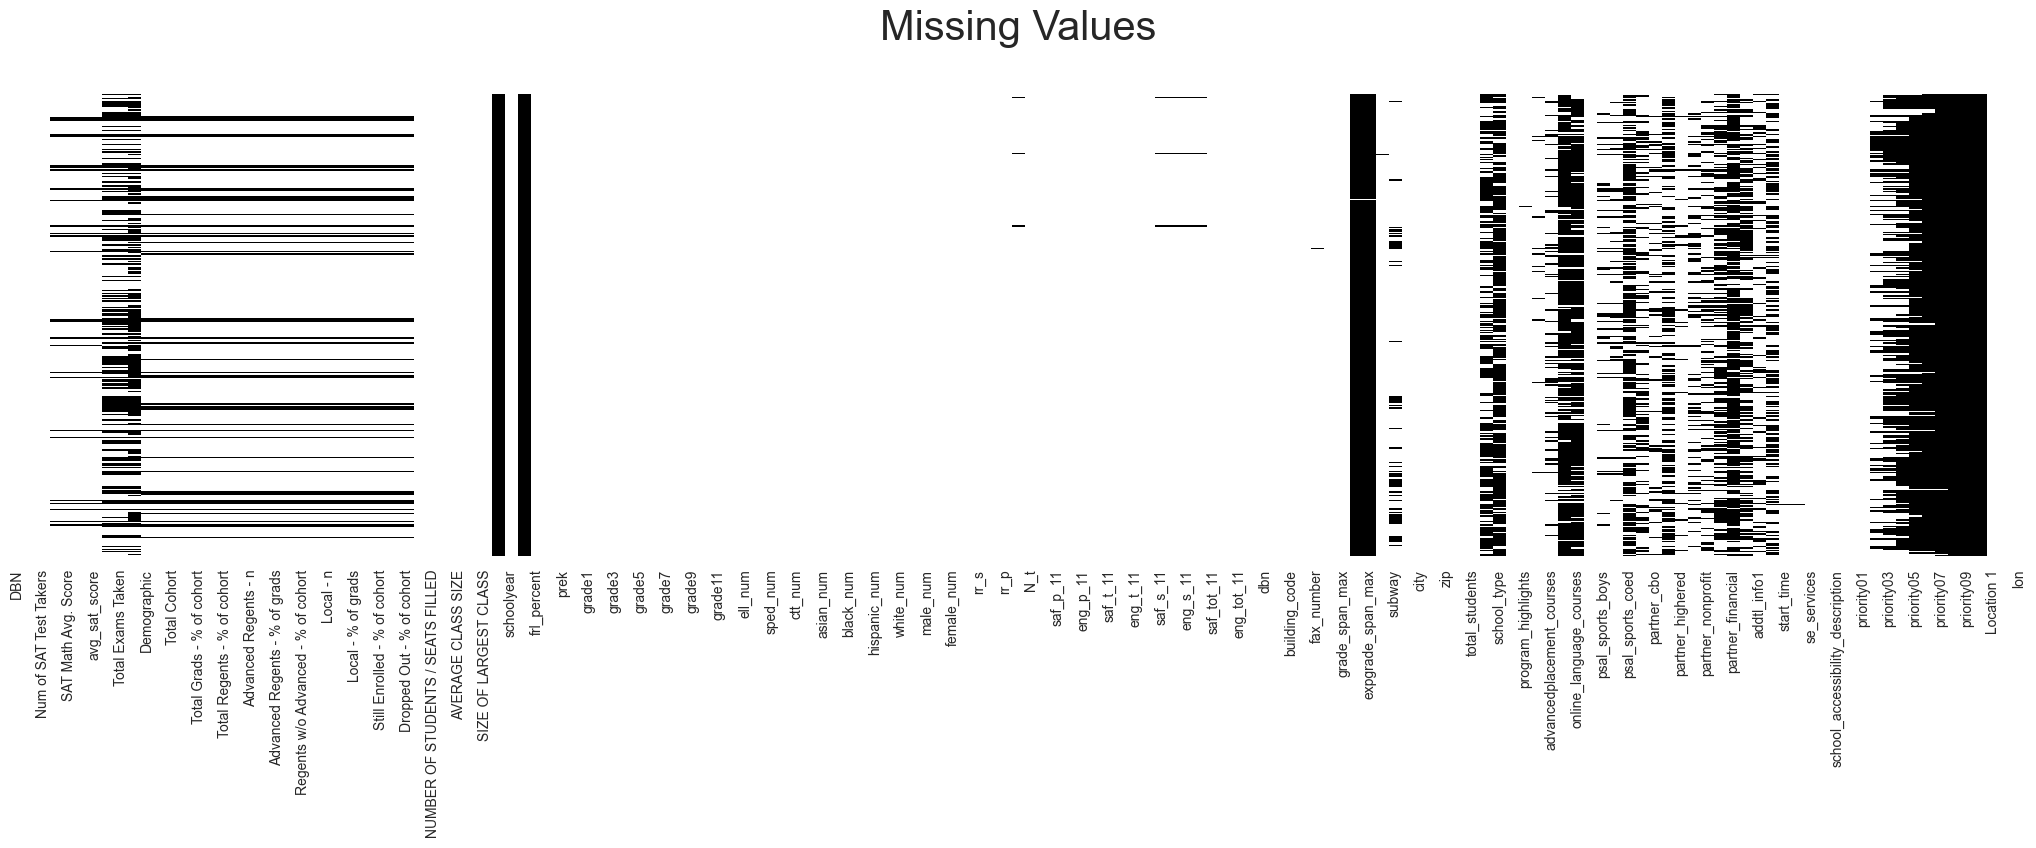

In [25]:
plt.figure(figsize=(26,6))
sns.heatmap(combined.isnull(),yticklabels=False,cbar=False,cmap="gray_r")
plt.title("Missing Values", y=1.10, fontsize=30)
plt.show()

In [26]:
sum(combined.isnull().sum())

8854

Merge order was experimented with. This was determined to be the best order, minimizing the null values to 8,854. Many of these null values are not required for our analysis.

---

### Handling Missing Data

Since we are concerned with correlations, we cannot have missing values in the dataset. As a result, nulls must be imputed.

The imputation strategy is as follows:

* Fill missing numeric values with the mean of their respective columns.

* For the remaining null values, fill with 0. To ensure issues do not arise with text-based columns, the `infer_objects()` method will be used to ensure object-type columns are converted to their appropriate inferred datatypes before filling with 0.

In [27]:
means = combined.mean(numeric_only=True)

combined = combined.fillna(means)

combined = combined.infer_objects(copy=False).fillna(0) # copy=False avoids making a copy of the dataframe

print(f"Nulls: {sum(combined.isnull().sum())}")

Nulls: 0


In [28]:
combined.head(3)

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,avg_sat_score,AP Test Takers,Total Exams Taken,Number of Exams with scores 3 4 or 5,Demographic,Cohort,Total Cohort,Total Grads - n,Total Grads - % of cohort,Total Regents - n,Total Regents - % of cohort,Total Regents - % of grads,Advanced Regents - n,Advanced Regents - % of cohort,Advanced Regents - % of grads,Regents w/o Advanced - n,Regents w/o Advanced - % of cohort,Regents w/o Advanced - % of grads,Local - n,Local - % of cohort,Local - % of grads,Still Enrolled - n,Still Enrolled - % of cohort,Dropped Out - n,Dropped Out - % of cohort,CSD,NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,SCHOOLWIDE PUPIL-TEACHER RATIO,schoolyear,fl_percent,frl_percent,total_enrollment,prek,k,grade1,grade2,grade3,grade4,grade5,grade6,grade7,grade8,grade9,grade10,grade11,grade12,ell_num,ell_percent,sped_num,sped_percent,ctt_num,selfcontained_num,asian_num,asian_per,black_num,black_per,hispanic_num,hispanic_per,white_num,white_per,male_num,male_per,female_num,female_per,rr_s,rr_t,rr_p,N_s,N_t,N_p,saf_p_11,com_p_11,eng_p_11,aca_p_11,saf_t_11,com_t_11,eng_t_11,aca_t_11,saf_s_11,com_s_11,eng_s_11,aca_s_11,saf_tot_11,com_tot_11,eng_tot_11,aca_tot_11,dbn,boro,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,bus,subway,primary_address_line_1,city,state_code,zip,website,total_students,campus_name,school_type,overview_paragraph,program_highlights,language_classes,advancedplacement_courses,online_ap_courses,online_language_courses,extracurricular_activities,psal_sports_boys,psal_sports_girls,psal_sports_coed,school_sports,partner_cbo,partner_hospital,partner_highered,partner_cultural,partner_nonprofit,partner_corporate,partner_financial,partner_other,addtl_info1,addtl_info2,start_time,end_time,se_services,ell_programs,school_accessibility_description,number_programs,priority01,priority02,priority03,priority04,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,lat,lon
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355.0,404.0,363.0,1122.0,129.028846,197.038462,153.45,Total Cohort,2006,78.0,43,55.1%,36,46.2%,83.7%,0,0%,0%,36,46.2%,83.7%,7,9%,16.3%,16,20.5%,11,14.1%,1.0,88.0000,4.000000,22.564286,18.50,26.571429,0.0,20112012,0.0,88.6,422,,,,,,,,32,33,50,98,79,80,50,94.0,22.3,105.0,24.9,34,35,59,14.0,123,29.1,227,53.8,7,1.7,259.0,61.4,163.0,38.6,89.0,70,39,379.000000,26.0,151.0,7.8,7.7,7.4,7.6,6.3,5.3,6.1,6.5,6.000000,5.600000,6.100000,6.700000,6.7,6.2,6.6,7.0,01M292,Manhattan,M056,212-406-9411,212-406-9417,6,12,0,12.0,"B39, M14A, M14D, M15, M15-SBS, M21, M22, M9","B, D to Grand St ; F to East Broadway ; J, M, ...",220 Henry Street,New York,NY,10002,http://schools.nyc.gov/schoolportals/01/M292,323.0,0,0,Henry Street School for International Studies ...,"Global/International Studies in core subjects,...","Chinese (Mandarin), Spanish",Psychology,"Chinese Language and Culture, Spanish Literatu...","Chinese (Mandarin), Spanish","Math through Card Play; Art, Poetry/Spoken Wor...",Basketball,Softball,Soccer,"Boxing, Track, CHAMPS, Tennis, Flag Football, ...",The Henry Street Settlement; Asia Society; Ame...,Gouverneur Hospital (Turning Points),New York University,Asia Society,Heart of America Foundation,0,0,United Nations,0,0,8:30 AM,3:30 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to continuing 8th graders,Then to Manhattan students or residents who at...,Then to New York City residents who attend an ...,Then to Manhattan students or residents,Then to New York City residents,0,0,0.0,0.0,0.0,"220 Henry Street\nNew York, NY 10002\n(40.7137...",40.713764,-73.985260
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383.0,423.0,366.0,1172.0,39.000000,49.000000,10.00,Total Cohort,2006,124.0,53,42.7%,42,33.9%,79.2%,8,6.5%,15.1%,34,27.4%,64.2%,11,8.9%,2

### Adding a School District Code Column

After handling the null values, we can create a new school district code column to enable us to look for geopgraphical patterns.

In [29]:
def extract_csd(dbn):
    return dbn[0:2]

# de-fragment the DataFrame before inserting a new column to avoid a PerformanceWarning
# since  many small column inserts have been performed elsewhere. Making a copy consolidates memory blocks.
combined = combined.copy()

# use vectorized string slicing instead of apply for speed and clarity
combined["school_dist"] = combined["DBN"].str.slice(0, 2)

combined.head(3)

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,avg_sat_score,AP Test Takers,Total Exams Taken,Number of Exams with scores 3 4 or 5,Demographic,Cohort,Total Cohort,Total Grads - n,Total Grads - % of cohort,Total Regents - n,Total Regents - % of cohort,Total Regents - % of grads,Advanced Regents - n,Advanced Regents - % of cohort,Advanced Regents - % of grads,Regents w/o Advanced - n,Regents w/o Advanced - % of cohort,Regents w/o Advanced - % of grads,Local - n,Local - % of cohort,Local - % of grads,Still Enrolled - n,Still Enrolled - % of cohort,Dropped Out - n,Dropped Out - % of cohort,CSD,NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,SCHOOLWIDE PUPIL-TEACHER RATIO,schoolyear,fl_percent,frl_percent,total_enrollment,prek,k,grade1,grade2,grade3,grade4,grade5,grade6,grade7,grade8,grade9,grade10,grade11,grade12,ell_num,ell_percent,sped_num,sped_percent,ctt_num,selfcontained_num,asian_num,asian_per,black_num,black_per,hispanic_num,hispanic_per,white_num,white_per,male_num,male_per,female_num,female_per,rr_s,rr_t,rr_p,N_s,N_t,N_p,saf_p_11,com_p_11,eng_p_11,aca_p_11,saf_t_11,com_t_11,eng_t_11,aca_t_11,saf_s_11,com_s_11,eng_s_11,aca_s_11,saf_tot_11,com_tot_11,eng_tot_11,aca_tot_11,dbn,boro,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,bus,subway,primary_address_line_1,city,state_code,zip,website,total_students,campus_name,school_type,overview_paragraph,program_highlights,language_classes,advancedplacement_courses,online_ap_courses,online_language_courses,extracurricular_activities,psal_sports_boys,psal_sports_girls,psal_sports_coed,school_sports,partner_cbo,partner_hospital,partner_highered,partner_cultural,partner_nonprofit,partner_corporate,partner_financial,partner_other,addtl_info1,addtl_info2,start_time,end_time,se_services,ell_programs,school_accessibility_description,number_programs,priority01,priority02,priority03,priority04,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,lat,lon,school_dist
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355.0,404.0,363.0,1122.0,129.028846,197.038462,153.45,Total Cohort,2006,78.0,43,55.1%,36,46.2%,83.7%,0,0%,0%,36,46.2%,83.7%,7,9%,16.3%,16,20.5%,11,14.1%,1.0,88.0000,4.000000,22.564286,18.50,26.571429,0.0,20112012,0.0,88.6,422,,,,,,,,32,33,50,98,79,80,50,94.0,22.3,105.0,24.9,34,35,59,14.0,123,29.1,227,53.8,7,1.7,259.0,61.4,163.0,38.6,89.0,70,39,379.000000,26.0,151.0,7.8,7.7,7.4,7.6,6.3,5.3,6.1,6.5,6.000000,5.600000,6.100000,6.700000,6.7,6.2,6.6,7.0,01M292,Manhattan,M056,212-406-9411,212-406-9417,6,12,0,12.0,"B39, M14A, M14D, M15, M15-SBS, M21, M22, M9","B, D to Grand St ; F to East Broadway ; J, M, ...",220 Henry Street,New York,NY,10002,http://schools.nyc.gov/schoolportals/01/M292,323.0,0,0,Henry Street School for International Studies ...,"Global/International Studies in core subjects,...","Chinese (Mandarin), Spanish",Psychology,"Chinese Language and Culture, Spanish Literatu...","Chinese (Mandarin), Spanish","Math through Card Play; Art, Poetry/Spoken Wor...",Basketball,Softball,Soccer,"Boxing, Track, CHAMPS, Tennis, Flag Football, ...",The Henry Street Settlement; Asia Society; Ame...,Gouverneur Hospital (Turning Points),New York University,Asia Society,Heart of America Foundation,0,0,United Nations,0,0,8:30 AM,3:30 PM,This school will provide students with disabil...,ESL,Functionally Accessible,1,Priority to continuing 8th graders,Then to Manhattan students or residents who at...,Then to New York City residents who attend an ...,Then to Manhattan students or residents,Then to New York City residents,0,0,0.0,0.0,0.0,"220 Henry Street\nNew York, NY 10002\n(40.7137...",40.713764,-73.985260,01
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383.0,423.0,366.0,1172.0,39.000000,49.000000,10.00,Total Cohort,2006,124.0,53,42.7%,42,33.9%,79.2%,8,6.5%,15.1%,34,27.4%,

#### Aggregating the Dataset by School District

In order to get insight into school district-level variations, we can aggregate the merged dataset by school district.

There are 31 distinct community school districts in NYC. This [source](https://www.schools.nyc.gov/docs/default-source/default-document-library/nycdoe-district-mape429391a3b194b8ab106abb1d2ee44ca.pdf) provides a map and breakdown of where each geographic location falls on the district-level map.

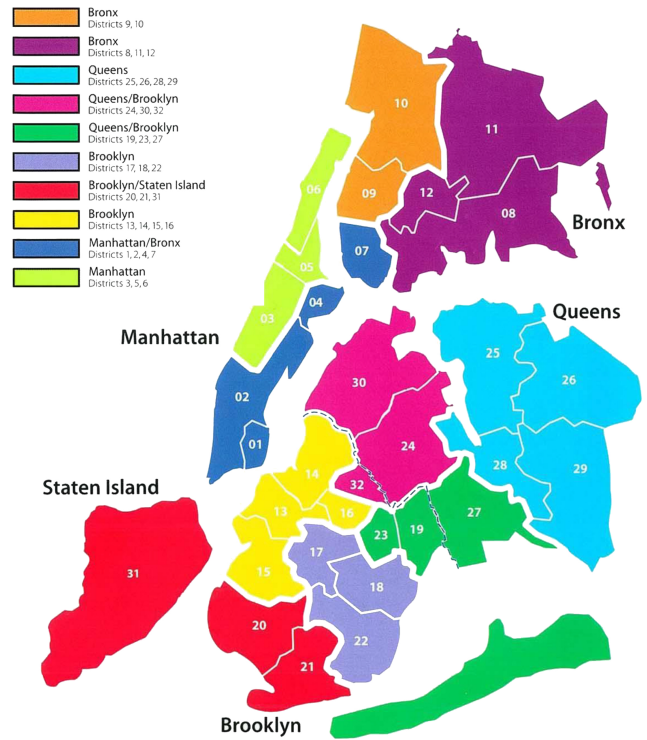

In [30]:
combined_by_dist = combined.groupby("school_dist").agg("mean", numeric_only=True)

combined_by_dist[["avg_sat_score"]].sort_values(by="avg_sat_score", ascending=False)

,avg_sat_score
school_dist,
22,1450.500000
31,1382.500000
26,1377.600000
25,1357.000000
01,1354.500000
28,1347.846947
30,1326.382090
02,1295.638184
03,1293.443035


It appears there are many Brooklyn and Bronx districts that have **low** average SAT scores, whilst Staten Island districts seem to perform the best in the SAT when all schools are averaged.

To remove some of the granularity, we can also group by borough:

In [31]:
combined_by_boro = combined.groupby("boro").agg("mean", numeric_only=True)

combined_by_boro[["avg_sat_score"]].sort_values(by="avg_sat_score", ascending=False)

,avg_sat_score
boro,
Staten Island,1382.500000
Queens,1286.753032
Manhattan,1278.331410
Brooklyn,1181.364461
Bronx,1157.598203


This supports the observation above.

Generally, it appears schools based in certain areas of Brooklyn and the Bronx typically perform the worst on the SAT. Both of the aggregated average SAT scores for these two boroughs are approximately 100 points *lower* than the third worst performing borough (Manhattan).

## Analysis

Typically, a Pearson's r value with an **absolute value** greater than 0.25 is a relationship of interest. It does not necessarily mean there is a correlation, but warrants further investigation.

#### Pearson Correlation Coefficients for Variables of Interest

In [32]:
correlations = combined.corr(numeric_only=True)

correlations = correlations[["avg_sat_score"]].sort_values(by="avg_sat_score", ascending=False)

In [33]:
correlations_of_interest = correlations[correlations["avg_sat_score"].abs() > 0.25] # filter to only those fields with a correlation greater than 0.25 or less than -0.25

correlations_of_interest = correlations_of_interest.drop(index=["avg_sat_score"]) # drop the self-correlation row

correlations_of_interest

,avg_sat_score
SAT Writing Avg. Score,0.987771
SAT Critical Reading Avg. Score,0.986820
SAT Math Avg. Score,0.972643
white_per,0.620718
asian_per,0.570730
AP Test Takers,0.523140
Total Exams Taken,0.514333
asian_num,0.475445
Number of Exams with scores 3 4 or 5,0.463245
white_num,0.449559


In [34]:
correlations_of_interest.shape[0]

31

There are 31 fields with a Pearson correlation coefficent meeting the criteria of an absolute value greater than 0.25.

#### Gender of the Student Body

In [35]:
correlations.loc[["male_per","female_per"], :]

,avg_sat_score
male_per,-0.112062
female_per,0.112108


#### Student, Teacher and Parent School Safety Survey Responses

In [36]:
correlations.loc[["saf_s_11","saf_t_11", "saf_p_11"], :]

,avg_sat_score
saf_s_11,0.337639
saf_t_11,0.313810
saf_p_11,0.122913


#### Student, Teacher and Parent Academic Standards Survey Responses

In [37]:
correlations.loc[["aca_s_11","aca_t_11", "aca_p_11"], :]

,avg_sat_score
aca_s_11,0.339435
aca_t_11,0.132348
aca_p_11,0.035155


#### Ethnicity of the Student Body

In [38]:
correlations.loc[["white_per","black_per","hispanic_per","asian_per"], :]

,avg_sat_score
white_per,0.620718
black_per,-0.284139
hispanic_per,-0.396985
asian_per,0.570730


#### Students with Low Household Income Background

In [39]:
correlations.loc[["frl_percent"], :]

,avg_sat_score
frl_percent,-0.722225


#### Observations from the listed Pearson r values above:

*	Unsurprisingly, `SAT Writing Avg. Score`, `SAT Critical Reading Avg. Score` and `SAT Math Avg. Score` are strongly correlated with `avg_sat_score`. 

* `Total_enrollment` has a positive correlation (0.37) which indicates larger schools tend to perform better on the SAT. This trend is shared across other proxies for enrolment (`total_students`, `N_s`, `N_p`, `N_t`, `AP Test Takers`, `Total Exams Taken` and `NUMBER OF SECTIONS`).

* The `female_per` field correlates positively with SAT score whilst `male_per` correlates negatively. This could suggest women do better on the SAT than men. 

* Teacher and student ratings of school safety (`saf_s_11` and `saf_t_11`) correlate positively with SAT scores.

* Student ratings of school academic standards (`aca_s_11`) correlate positively with SAT scores, but the strength of this relationship does *not* hold to the same extent for teacher and parent ratings (`aca_t_11` and `aca_p_11`).

* There seems to be significant racial inequality in SAT scores (correlations with `white_per`, `black_per`, `hispanic_per` and `asian_per` all widely vary).

* The percentage of students eligible for free/reduced-cost school lunch based on household income (`frl_percent`) has a negative correlation with SAT scores.


#### Visualizing the Relationship between Total Enrollment and Avg. SAT score

Curiously, the data suggests schools with a larger number of enrolled students tend to have greater average SAT scores. We may expect the opposite since we can reason that a large class size would lead to more poorly tailored teaching for individual students. 

To verify the relationship, we can dig deeper and visualize the data with a scatter plot.

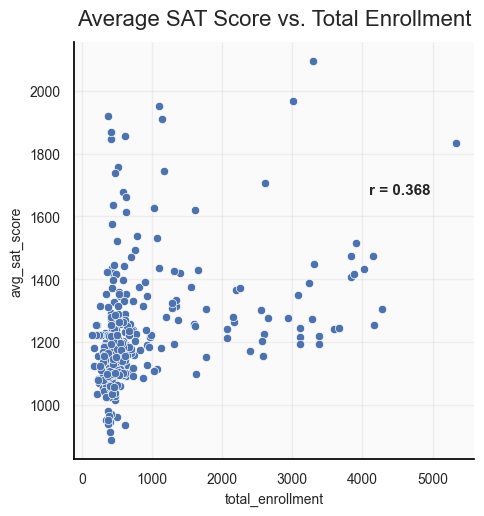

In [40]:
sns.relplot(x="total_enrollment", y="avg_sat_score", data=combined)
plt.title("Average SAT Score vs. Total Enrollment", y=1.02, fontsize=16)
plt.text(4100, 1670, f"r = {combined.corr(numeric_only=True)['avg_sat_score']['total_enrollment']:0.3f}", weight="bold", fontsize=11)

plt.show()

The scatter plot calls the positive correlation into question, there seem to be many more schools with a lower total enrollment with higher average SAT scores (typically, any school with over 2,000 enrolled students tend to have average SAT scores below 1,500 with few exceeding this).

There appears to be a **cluster of schools** in the bottom left where both the average SAT score and total number of students enrolled are low (where total enrollment and average SAT scores are both less than 1,000). It is worth looking into this cluster more closely to see if there is another variable that may be responsible for this observation, since this cluster has a significant influence on the Pearson r value (0.37).

In [41]:
low_enrollment_low_sat = combined[(combined["total_enrollment"] < 1000) & (combined["avg_sat_score"] < 1000)]

low_enrollment_low_sat[["SCHOOL NAME", "school_dist"]]

,SCHOOL NAME,school_dist
91,INTERNATIONAL COMMUNITY HIGH SCHOOL,07
125,ACADEMY FOR LANGUAGE AND TECHNOLOGY,09
126,BRONX INTERNATIONAL HIGH SCHOOL,09
139,KINGSBRIDGE INTERNATIONAL HIGH SCHOOL,10
141,INTERNATIONAL SCHOOL FOR LIBERAL ARTS,10
176,PAN AMERICAN INTERNATIONAL HIGH SCHOOL AT MONROE,12
179,HIGH SCHOOL OF WORLD CULTURES,12
188,BROOKLYN INTERNATIONAL HIGH SCHOOL,13
225,INTERNATIONAL HIGH SCHOOL AT PROSPECT HEIGHTS,17
237,IT TAKES A VILLAGE ACADEMY,18


Researching each of these institutions, many of these cater to immigrant students who are **English language learners**. This proportion of the student body is captured by the `ell_percent` field.

This indicates that `ell_percent` likely contributes significantly to the perceived correlation that the avg_sat_score has with `total_enrollment`.

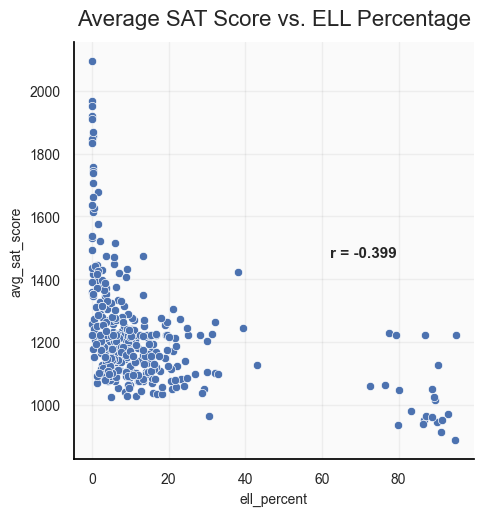

In [42]:
sns.relplot(x="ell_percent", y="avg_sat_score", data=combined)
plt.title("Average SAT Score vs. ELL Percentage", y=1.02, fontsize=16)
plt.text(62, 1470, f"r = {combined.corr(numeric_only=True)['avg_sat_score']['ell_percent']:0.3f}", weight="bold", fontsize=11)

plt.show()

Here, we show that all except one of the high schools with average SAT scores falling below 1,000 have a significant proportion (around 80% and above) of students classed as **English Language Learners** (those who are not fully proficient/fluent in the English language).

This could highlight difficulties immigrant communities face when adapting to the USA education system. 

**Two-thirds** of the SAT content consists of **English Reading** and **Writing** sections, which would be significantly more challenging for students who are not yet fluent.

## Mapping Out Schools with High ELL Percentage and Low SAT Scores

To gain insight into whether there are any geographical patterns associated with the schools with high ELL student bodies and low SAT scores, we can create a visualization to map out where these schools are located.

In [43]:
high_ell_percent_low_sat = low_enrollment_low_sat.copy()

In [44]:
high_ell_percent_low_sat[["DBN","SCHOOL NAME", "school_dist", "lat", "lon"]]

,DBN,SCHOOL NAME,school_dist,lat,lon
91,07X334,INTERNATIONAL COMMUNITY HIGH SCHOOL,07,40.810036,-73.917812
125,09X365,ACADEMY FOR LANGUAGE AND TECHNOLOGY,09,40.849102,-73.916088
126,09X403,BRONX INTERNATIONAL HIGH SCHOOL,09,40.827603,-73.904475
139,10X268,KINGSBRIDGE INTERNATIONAL HIGH SCHOOL,10,40.870377,-73.898163
141,10X342,INTERNATIONAL SCHOOL FOR LIBERAL ARTS,10,40.870377,-73.898163
176,12X388,PAN AMERICAN INTERNATIONAL HIGH SCHOOL AT MONROE,12,40.831366,-73.878823
179,12X550,HIGH SCHOOL OF WORLD CULTURES,12,40.831366,-73.878823
188,13K439,BROOKLYN INTERNATIONAL HIGH SCHOOL,13,40.697175,-73.984960
225,17K524,INTERNATIONAL HIGH SCHOOL AT PROSPECT HEIGHTS,17,40.670299,-73.961648
237,18K563,IT TAKES A VILLAGE ACADEMY,18,40.648664,-73.921899


Looking closely at the data, there are two pairs of schools that operate from the exact same location (`10X268` & `10X342` and `12X388` & `12X550`). Presumably these institutions are highly related to one another (since they operate from the same geographic location), even though they are considered to be separate schools.

This gives us 10 distinct geopgraphic locations.

In [45]:
schools_without_high_ell_low_sat = combined.drop(high_ell_percent_low_sat.index)

schools_without_high_ell_low_sat.shape[0]

351

To gain an idea about the spatial distribution of these schools, we first filter the `combined` dataframe to remove the high ELL, low SAT scoring schools. We can then plot the latitude and longitude data for both dataframes above onto a scatter plot to map out the schools geographically.

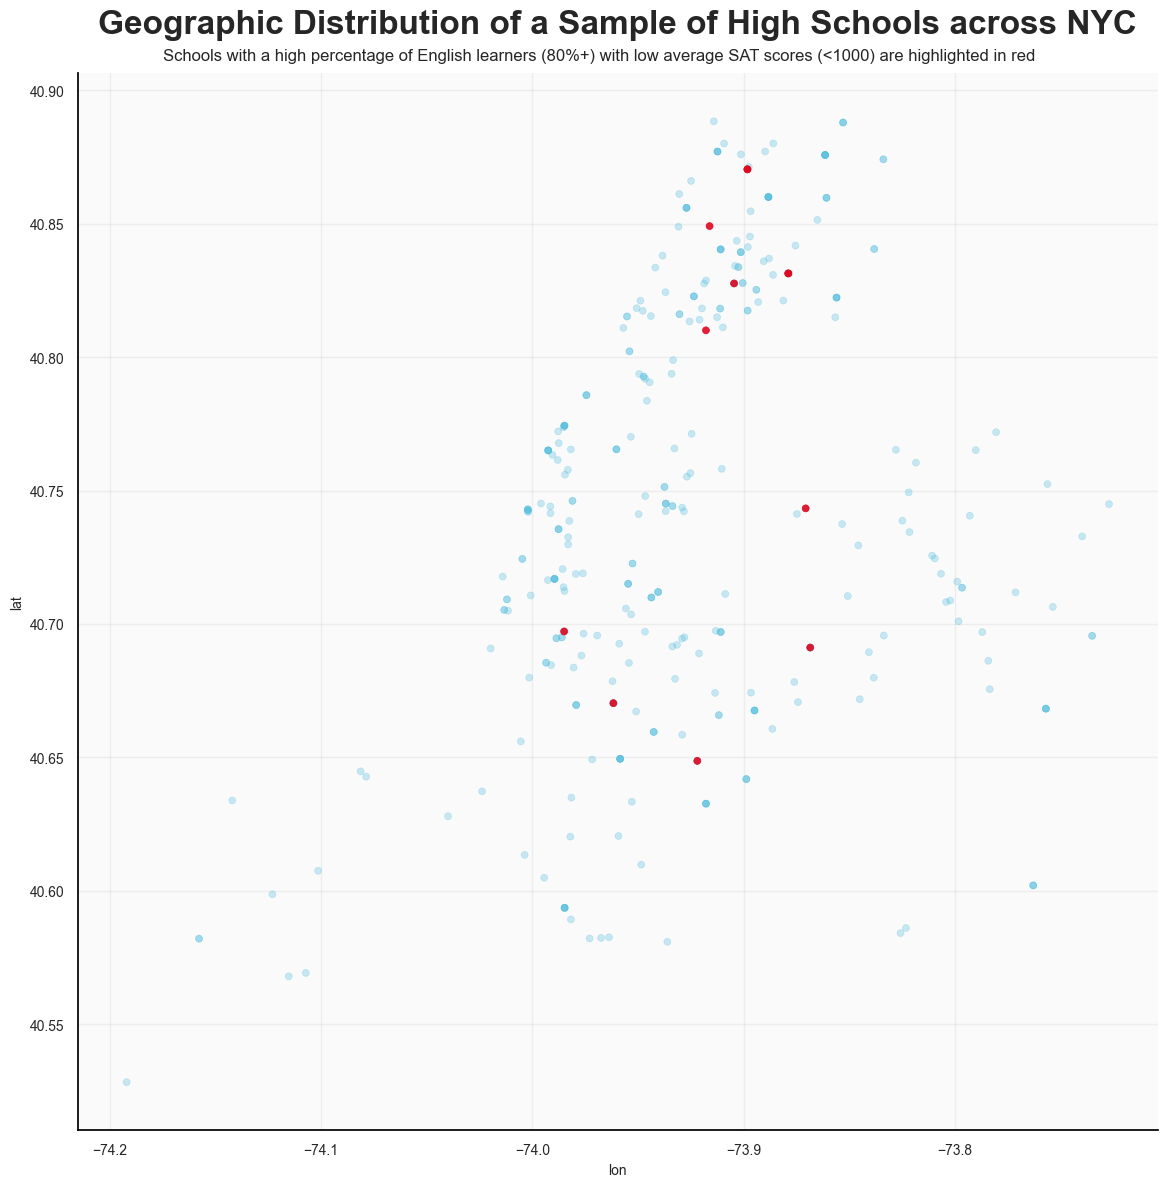

In [46]:
import seaborn.objects as so

# configure seaborn to display the plot as a scalable vector graphic
so.Plot.config.display["format"] = "svg"

# create plot of school geographic locations using seaborns object oriented interface
fig, ax = plt.subplots(figsize=(12, 12))

(
so.Plot(data=schools_without_high_ell_low_sat, x="lon", y="lat")
  .add(so.Dot(pointsize=5, alpha=0.3, color="#50bdde"))
  .on(ax)
  .plot()
)

(
so.Plot(data=high_ell_percent_low_sat, x="lon", y="lat")
  .add(so.Dot(pointsize=5, alpha=0.9, color="#e00720"))
  .on(ax)
  .plot()
)

plt.title("Geographic Distribution of a Sample of High Schools across NYC", y=1.03, fontsize=24, weight="bold")
ax.text(-74.175, 40.9115,"Schools with a high percentage of English learners (80%+) with low average SAT scores (<1000) are highlighted in red", fontsize=12)

plt.tight_layout()

plt.savefig("nyc_high_schools_map.svg")

plt.show()

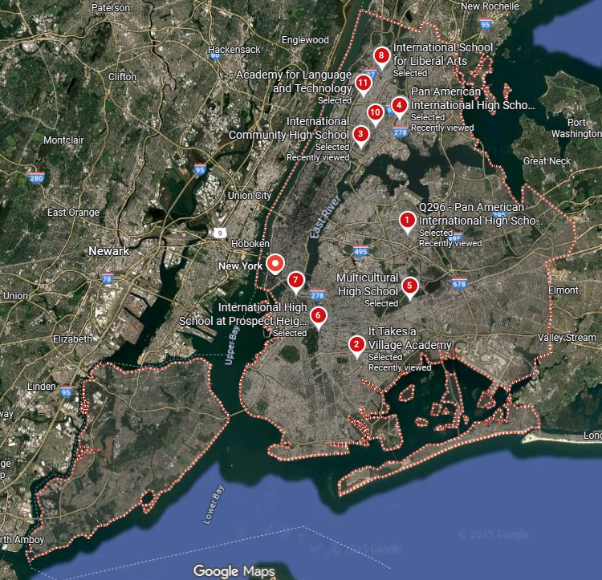

Source: [Google Maps](https://www.google.com/maps/place/New+York,+NY,+USA/@40.6572142,-74.4407357,155459m/data=!3m1!1e3!4m6!3m5!1s0x89c24fa5d33f083b:0xc80b8f06e177fe62!8m2!3d40.7127753!4d-74.0059728!16zL20vMDJfMjg2?entry=ttu&g_ep=EgoyMDI1MDkyNC4wIKXMDSoASAFQAw%3D%3D)

In [47]:
high_ell_percent_low_sat[["DBN","SCHOOL NAME", "school_dist", "lat", "lon"]]

,DBN,SCHOOL NAME,school_dist,lat,lon
91,07X334,INTERNATIONAL COMMUNITY HIGH SCHOOL,07,40.810036,-73.917812
125,09X365,ACADEMY FOR LANGUAGE AND TECHNOLOGY,09,40.849102,-73.916088
126,09X403,BRONX INTERNATIONAL HIGH SCHOOL,09,40.827603,-73.904475
139,10X268,KINGSBRIDGE INTERNATIONAL HIGH SCHOOL,10,40.870377,-73.898163
141,10X342,INTERNATIONAL SCHOOL FOR LIBERAL ARTS,10,40.870377,-73.898163
176,12X388,PAN AMERICAN INTERNATIONAL HIGH SCHOOL AT MONROE,12,40.831366,-73.878823
179,12X550,HIGH SCHOOL OF WORLD CULTURES,12,40.831366,-73.878823
188,13K439,BROOKLYN INTERNATIONAL HIGH SCHOOL,13,40.697175,-73.984960
225,17K524,INTERNATIONAL HIGH SCHOOL AT PROSPECT HEIGHTS,17,40.670299,-73.961648
237,18K563,IT TAKES A VILLAGE ACADEMY,18,40.648664,-73.921899


Mapping out the schools with a high ELL percentage and average SAT scores less than 1000, we see two main areas of the city where these schools predominate: 

* A cluster of schools are observed in **The Bronx** borough of the city. These cover the seven schools `07X334` to `12X550` listed above.

* Another group of five schools can be observed, though more spread. Four of the five (`13K439`, `17K524`, `18K563` and `19K583`) fall within the **Brooklyn** borough with the remaining (`24Q286`) lying in the **Queens** borough.

The distribution of these schools seems somewhat localised to specific areas primarily within The Bronx and Brooklyn boroughs. According to historical [census data](https://archive.ph/20200212043233/http://factfinder.census.gov/servlet/GCTTable?_bm=y&-geo_id=04000US36&-ds_name=DEC_2000_SF1_U&-_lang=en&-redoLog=false&-format=ST-2&-mt_name=DEC_2000_SF1_U_GCTP6_ST2&-CONTEXT=gct) gathered in 2000, these boroughs were especially (and [continue to be](https://en.wikipedia.org/wiki/Race_and_ethnicity_in_New_York_City#Diversity_of_New_York_City's_boroughs)) diverse, deviating from the typical predominant white-american ethnicity and containing a large proportion of foreign-born residents. 

This certainly explains the large proportion of students who are English language learners in these schools (who presumably cater for immigrant communities who do not speak English as a first-language).

---

## Class Size vs. Average SAT Scores

Since we looked at the `total_enrollment` field above, it is of interest to look closer into a related variable which can act as a proxy for `total_enrollment`. This will give us a better understanding of the patterns related to the size of a school and how this affects average SAT scores.

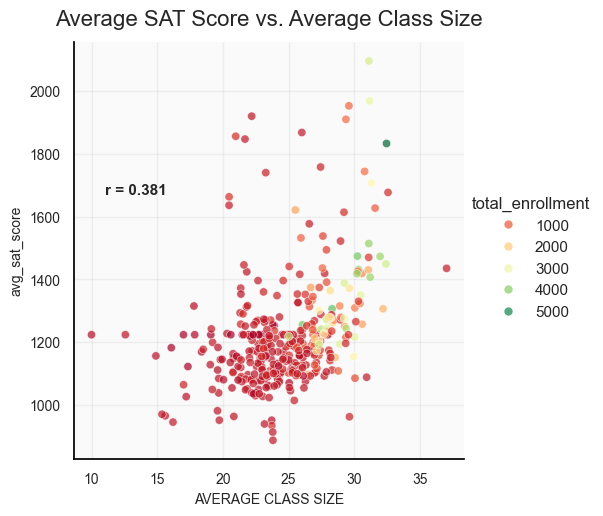

In [48]:
sns.relplot(x="AVERAGE CLASS SIZE", y="avg_sat_score", hue="total_enrollment", palette="RdYlGn", data=combined, alpha=0.7)
plt.title("Average SAT Score vs. Average Class Size", y=1.02, fontsize=16)
plt.text(11, 1670, f"r = {combined.corr(numeric_only=True)['avg_sat_score']['AVERAGE CLASS SIZE']:0.3f}", weight="bold", fontsize=11)

plt.show()

There is a positive correlation between average SAT score and average class size, though the strength of the correlation is somewhat weak. As previously uncovered, SAT score is correlated with the `total_enrollment` field, hence the enrollment field has been visualized as a third variable on the relational plot above. 

It does appear that schools with a significantly large number of students enrolled (exceeding 2,000) do seem to have elevated average SAT scores. This could be because these schools receive far more funding and hence, are better equipped to deliver high quality teaching. 

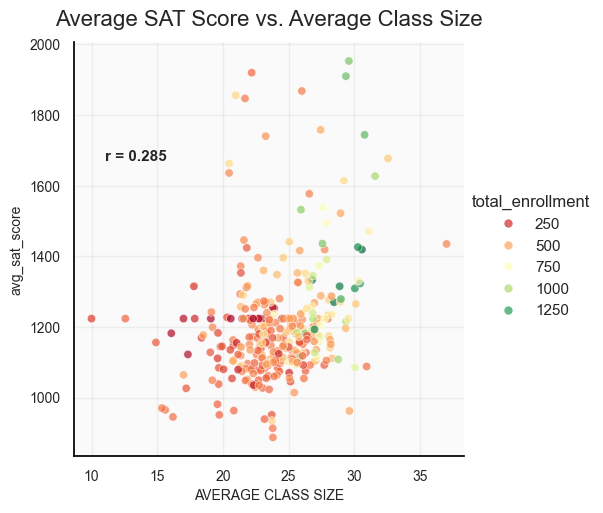

In [49]:
combined_without_high_enrollment = combined[combined["total_enrollment"] < 1500]

sns.relplot(x="AVERAGE CLASS SIZE", y="avg_sat_score", hue="total_enrollment", palette="RdYlGn", data=combined_without_high_enrollment, alpha=0.7)
plt.title("Average SAT Score vs. Average Class Size", y=1.02, fontsize=16)
plt.text(11, 1670, f"r = {combined_without_high_enrollment.corr(numeric_only=True)['avg_sat_score']['AVERAGE CLASS SIZE']:0.3f}", weight="bold", fontsize=11)

plt.show()

Removal of the schools with significantly high enrollment numbers (> 1,500) has noticeably weakened the correlation. This suggests the relationship between average SAT score and average class size is weak and is likely the result of the `total_enrollment` field acting as a **nuisance factor**.

## Correlations Between SAT Scores and Survey Data

In [50]:
survey_fields.remove("DBN") # remove DBN from the list of survey fields since it is not numeric and will otherwise cause an error

In [51]:
survey_fields

['rr_s',
 'rr_t',
 'rr_p',
 'N_s',
 'N_t',
 'N_p',
 'saf_p_11',
 'com_p_11',
 'eng_p_11',
 'aca_p_11',
 'saf_t_11',
 'com_t_11',
 'eng_t_11',
 'aca_t_11',
 'saf_s_11',
 'com_s_11',
 'eng_s_11',
 'aca_s_11',
 'saf_tot_11',
 'com_tot_11',
 'eng_tot_11',
 'aca_tot_11']

**As mentioned prior:**

The data dictionary for the survey is publically available on the [NYC Open Data](https://data.cityofnewyork.us/Education/2011-NYC-School-Survey/mnz3-dyi8/about_data) and is provided directly in [this repo](https://github.com/Benkly/python-data-analysis-projects/tree/master/usa_sat_exam_scores/data_dictionaries\nyc_school_survey_2011.csv).

The survey fields listed have some relevance to our analysis:

* `DBN` - School unique identifier
* `rr_s` - Student Response Rate
* `rr_t` - Teacher Response Rate
* `rr_p` - Parent/Carer Response Rate
* `N_s` - Number of Student Respondants
* `N_t` - Number of Teacher Respondants
* `N_p` - Number of Parent/Carer Respondants

* Fields beginning with `saf` refer to the Safety and Respect Score for the school. For instance, `saf_p_11` refers to the derived safety score from *parent* (p) survey responses in 2011.

* Fields beginning with `com` refer to the Communication Score for the school

* Fields beginning with `eng` refer to the Engagement Score for the school

* Fields beginning with `aca` refer to the Academic Expectations Score for the school

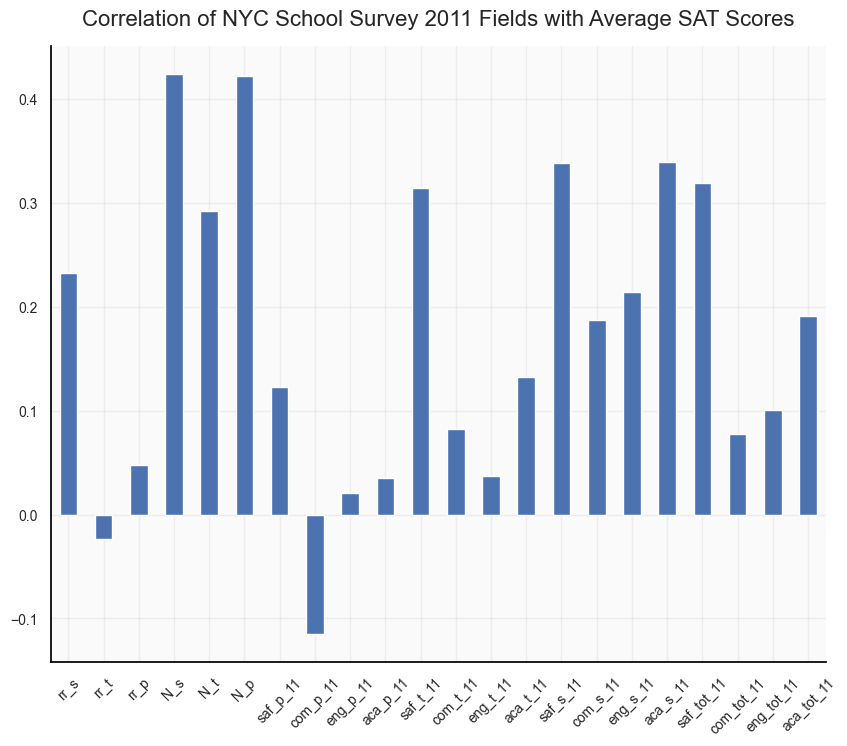

In [52]:
combined.corr(numeric_only=True)["avg_sat_score"][survey_fields].plot.bar(figsize=(10,8), rot=45)
plt.title("Correlation of NYC School Survey 2011 Fields with Average SAT Scores", y=1.02, fontsize=16)

plt.show()

In [53]:
correlations[correlations.index.isin(survey_fields)]

,avg_sat_score
N_s,0.423463
N_p,0.421530
aca_s_11,0.339435
saf_s_11,0.337639
saf_tot_11,0.318753
saf_t_11,0.313810
N_t,0.291463
rr_s,0.232199
eng_s_11,0.213822
aca_tot_11,0.190966


#### Remarks

* There are high correlations between `N_s`, `N_t` and `N_p` with avg SAT score. This makes sense - since each of the number of respondant columns are correlated with `total_enrollment`, we expect the correlation to also be similar.

* Interestingly, there is a relatively significant correlation (0.23) between the student response rate `rr_s` (the percentage of the school's student body who completed the survey) and average SAT score. This could be because students who are more likely to complete a survey are also more inclined to complete assignments/do more academic work, increasing the likelihood they will perform better on SAT exams.

* The above point is in contrast to the teacher and parent response rate fields (`rr_t` and `rr_p`), with neither showing a significant correlation. Again, this makes sense in the context of the data. The students themselves are responsible for their performance on the SAT - variables such as the percentage of parents and teachers that complete a survey has no bearing on the students or their ability to perform well on an exam, hence the lack of correlation.

* Both the student and teacher perception of school safety (`saf_s_11` and `saf_t_11`) show relatively significant correlations with average SAT score (at 0.34 and 0.31 respectively). This makes sense, since it would be more challenging to teach and study in an unsafe environment. 

* The `saf_p_11` field, representing the parents/carers perception of school safety shows a significantly weaker correlation with SAT performance (at 0.12). This is perhaps because parents/carers are typically less aware and not directly involved in the schooling process, meaning their perception and judgement is less likely to be a reliable indicator of the learning environment.

* The last notable correlation are the `aca` fields. The student perception of the school's academic standards (`aca_s_11`) correlate quite strongly with average SAT score (at 0.34). This does not hold true for the teacher and parent/carer perceptions (`aca_t_11` and `aca_p_11`, which come in at 0.13 and 0.03 respectively). This suggests the students themselves are the most reliable predictor of a school's teaching quality. An explanation for this could be: the students themselves are the recipients of many lessons and have no reason to be biased when judging the school's quality of teaching. A teacher (and parents especially) are likely to have a limited understanding of the quality of teaching across the entire school since these individuals are not recipients of the lessons.

## Exploring Safety Scores and SAT Performance

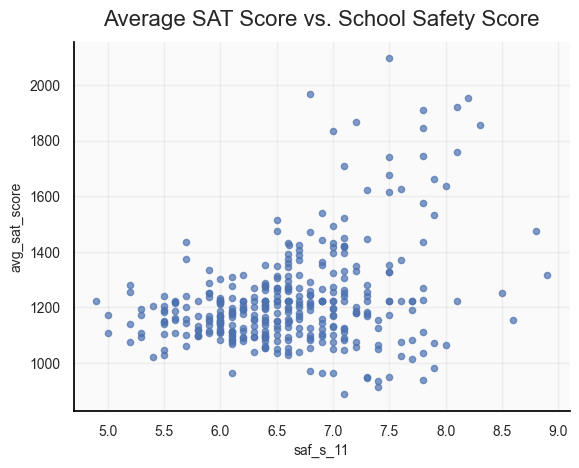

In [54]:
combined.plot.scatter(x="saf_s_11", y="avg_sat_score", alpha=0.7)
plt.title("Average SAT Score vs. School Safety Score", y=1.02, fontsize=16)

plt.show()

The above scatterplot visualizes the relationship between average SAT score and the student perception of school safety. The Pearson correlation coefficient between these two variables is 0.34 and is not especially strong. 

There are a handful of schools which have extremely high average SAT scores with relatively high safety ratings as well as examples of schools with low average SAT scores and low safety scores. Despite this, there are also examples that do not necessarily fit the trend (e.g., there are four schools with safety scores of 8.5 and above, but all have relatively **low** average SAT scores).

Generally, we do see that schools with a safety score lower than 6.5 do not have an average SAT score exceeding 1,500 or so.

#### Average Student Safety Score by District and Borough

In [55]:
combined_by_dist[["saf_s_11", "avg_sat_score"]].sort_values(by="saf_s_11", ascending=False)

,saf_s_11,avg_sat_score
school_dist,,
20,7.120000,1273.687761
12,7.116667,1101.823134
24,7.107692,1242.000000
30,7.033333,1326.382090
22,7.025000,1450.500000
06,6.950000,1164.643881
25,6.912500,1357.000000
02,6.910660,1295.638184
04,6.885714,1224.142857


In [56]:
combined_by_boro[["saf_s_11", "avg_sat_score"]].sort_values(by="saf_s_11", ascending=False)

,saf_s_11,avg_sat_score
boro,,
Manhattan,6.831370,1278.331410
Queens,6.721875,1286.753032
Bronx,6.606577,1157.598203
Staten Island,6.530000,1382.500000
Brooklyn,6.370755,1181.364461


Using the student safety scores for schools based in each district, we can gain insight into the more dangerous districts of NYC. 

From a higher-level perspective, we see that Manhattan and Queens are generally safer boroughs than the remaining three. Brooklyn is clearly the borough with the lowest average safety score, which likely means there are multiple dangerous areas within the Brooklyn borough of the city. 

Indeed, research into [dangerous boroughs of NYC](https://en.uhomes.com/blog/most-dangerous-neighbourhoods-in-nyc) corroborate these observations. Many of the neighborhoods with the greatest rate of crime are located in Brooklyn:

#### Brooklyn

* Brownsville (District 23)

* Bedford-Stuyvesant (District 16)

* East New York (District 19)

Other notable **dangerous** areas provided by the above source include:

#### The Bronx

* Mott Haven (District 7)

* Hunts Point (District 8)

* Fordham (District 10)

* East Tremont (District 12)


#### Queens

* Jamaica (near Brooklyn, District 27)

#### Manhattan

* East Harlem (near the Bronx, District 4)

Looking over the student safety scores grouped by district, many of these known dangerous neighborhoods do have relatively low safety scores. This is not a perfect trend (as we see District 12 with the second highest safety score, despite serving East Tremont which ranks in the top 10 neighborhoods with the greatest crime rate).

#### Staten Island

Interestingly, from the aggregated student safety score data, Staten Island has a relatively low student safety score (ranked fourth at 6.53). According to crime statistics, [Staten Island is the safest of all boroughs](https://furmancenter.org/neighborhoods/view/staten-island) in NYC, with 6.6 serious crimes per 1,000 people in 2024. This is less than twice the citywide crime rate of 13.6 serious crimes per 1,000 people in the same year. The source also provides historical data, which reveals the crime rate on Staten Island has remained steady over the last 20 years or so. The statistic located closest to the year the school survey data was gathered (2011) was 6.3 serious crimes per 1,000 in 2010, which is still considerably safer than the citywide crime rate.

It is **unclear** why the 2011 student safety score data for schools does not reflect the lower rate of crime in the borough. One theory could be that residents of Staten Island may have a different level of tolerance to danger since their borough has seen much less crime historically. Students in the Staten Island borough could be more likely to give harsher safety scores since they value safety in the community to a greater extent than students in boroughs where crime is more commonplace. This is highly speculative, so further studies into this would be necessary to make more concrete conclusions.

## Racial Differences in SAT Scores

As mentioned previously, the `demographics` dataset contains fields which indicate the percentage of white, asian, black and hispanic students from each school's student body (`white_per`, `asian_per`, ... ). This information can be used to identify any differences in SAT performance between these groups of students.

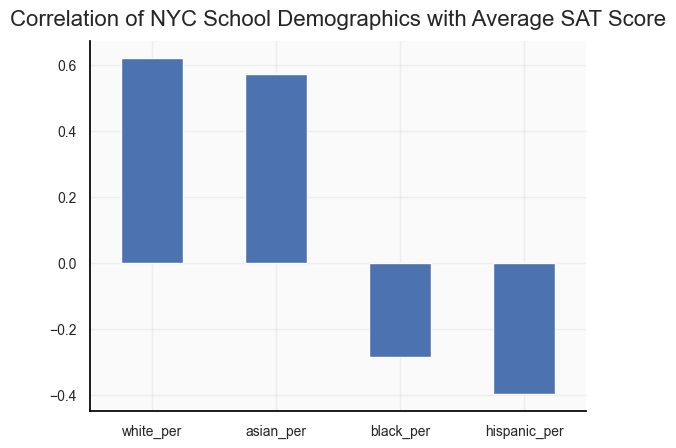

In [57]:
race_fields = ["white_per", "asian_per", "black_per", "hispanic_per"]

combined.corr(numeric_only=True)["avg_sat_score"][race_fields].plot.bar(rot=0)
plt.title("Correlation of NYC School Demographics with Average SAT Score", y=1.02, fontsize=16)

plt.show()

In [58]:
combined.corr(numeric_only=True)["avg_sat_score"][race_fields]

white_per       0.620718
asian_per       0.570730
black_per      -0.284139
hispanic_per   -0.396985
Name: avg_sat_score, dtype: float64

#### Remarks

* It appears schools with a higher percentage of white and asian students tend to have *elevated* average SAT scores. The strength of these correlations is relatively strong, with Pearson correlation coefficients around 0.60 in both cases.

* In contrast to this, schools with a higher percentage of black and hispanic students tend to have *lower* average SAT scores. The strength of these correlations is less strong, with Pearson correlation coefficients of -0.28 and -0.40 respectively.

One theory for these observations could be that schools based in certain areas lack funding and do not have access to sufficient resources as a result (staff, teaching materials etc.). These areas may have an elevated percentage of black and hispanic ethnicities, hence the poorer performance of students from these communities.

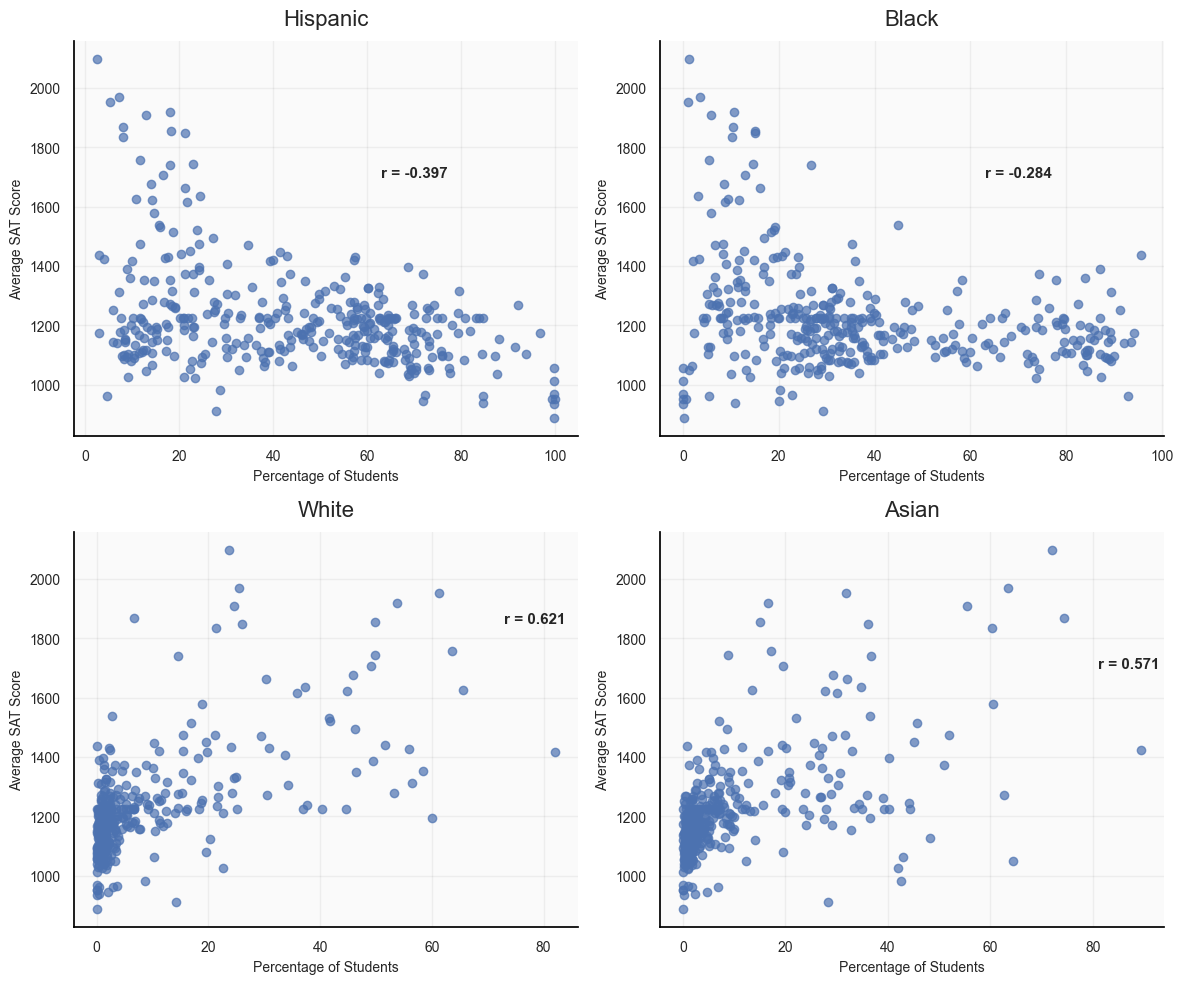

In [59]:
plt.figure(figsize=(12,10))

plt.subplot(2, 2, 1)

plt.scatter("hispanic_per", "avg_sat_score", data=combined, alpha=0.7)
plt.title("Hispanic", y=1.02, fontsize=16)
plt.xlabel("Percentage of Students", fontsize=10)
plt.ylabel("Average SAT Score", fontsize=10)
plt.text(63, 1700, "r = -0.397", fontsize=11, weight="bold")

plt.subplot(2, 2, 2)

plt.scatter("black_per", "avg_sat_score", data=combined, alpha=0.7)
plt.title("Black", y=1.02, fontsize=16)
plt.xlabel("Percentage of Students", fontsize=10)
plt.ylabel("Average SAT Score", fontsize=10)
plt.text(63, 1700, "r = -0.284", fontsize=11, weight="bold")

plt.subplot(2, 2, 3)

plt.scatter("white_per", "avg_sat_score", data=combined, alpha=0.7)
plt.title("White", y=1.02, fontsize=16)
plt.xlabel("Percentage of Students", fontsize=10)
plt.ylabel("Average SAT Score", fontsize=10)
plt.text(73, 1850, "r = 0.621", fontsize=11, weight="bold")

plt.subplot(2, 2, 4)

plt.scatter("asian_per", "avg_sat_score", data=combined, alpha=0.7)
plt.title("Asian", y=1.02, fontsize=16)
plt.xlabel("Percentage of Students", fontsize=10)
plt.ylabel("Average SAT Score", fontsize=10)
plt.text(81, 1700, "r = 0.571", fontsize=11, weight="bold")

plt.tight_layout()

plt.show()

#### Schools with a Significant Hispanic Student Population

In [60]:
combined[(combined["hispanic_per"] > 95)][["SCHOOL NAME", "hispanic_per", "ell_percent", "avg_sat_score"]]

,SCHOOL NAME,hispanic_per,ell_percent,avg_sat_score
44,MANHATTAN BRIDGES HIGH SCHOOL,99.8,72.6,1058.0
82,WASHINGTON HEIGHTS EXPEDITIONARY LEARNING SCHOOL,96.7,19.6,1174.0
89,GREGORIO LUPERON HIGH SCHOOL FOR SCIENCE AND M...,99.8,89.6,1014.0
125,ACADEMY FOR LANGUAGE AND TECHNOLOGY,99.4,86.6,951.0
141,INTERNATIONAL SCHOOL FOR LIBERAL ARTS,99.8,79.9,934.0
176,PAN AMERICAN INTERNATIONAL HIGH SCHOOL AT MONROE,99.8,92.9,970.0
253,MULTICULTURAL HIGH SCHOOL,99.8,94.6,887.0
286,PAN AMERICAN INTERNATIONAL HIGH SCHOOL,100.0,91.3,951.0


The listed schools with hispanic student percentages exceeding 95% all appear to primarily serve recent immigrants to the US. For instance, [Manhattan Bridges High School](https://insideschools.org/school/02M542) caters to newly arrived spanish-speaking immigrants.

We see a significant number of English language learning students across the list, which is likely a significant factor contributing to the low average SAT scores for these schools. 

[Washington Heights Expeditionary Learning School](https://insideschools.org/school/06M348) is an exception in the list above. This school does have a significant hispanic population, although many of these students are not considered English language learners at around 20%. This is still much higher than the citywide average, but it is significantly lower than schools that cater specifically for spanish-speaking immigrants. Looking into the school-level statistics, it appears this institution in particular has a **problem with student attendance**, with only 83% of students attending school daily (this is significantly lower than the 90% citywide average). This offers an alternative explanation for the relatively poor average SAT results for this school.

#### Schools with High Average SAT Scores

In [61]:
combined[(combined["avg_sat_score"] > 1800)][["SCHOOL NAME", "hispanic_per", "black_per", "asian_per", "white_per", "ell_percent", "frl_percent", "avg_sat_score"]].sort_values(by="avg_sat_score", ascending=False)

,SCHOOL NAME,hispanic_per,black_per,asian_per,white_per,ell_percent,frl_percent,avg_sat_score
37,STUYVESANT HIGH SCHOOL,2.4,1.2,72.1,23.7,0.0,30.3,2096.0
151,BRONX HIGH SCHOOL OF SCIENCE,7.2,3.5,63.5,25.4,0.1,34.2,1969.0
356,STATEN ISLAND TECHNICAL HIGH SCHOOL,5.3,1.1,31.8,61.3,0.1,17.0,1953.0
155,HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE,18.0,10.6,16.7,53.8,0.0,20.8,1920.0
302,TOWNSEND HARRIS HIGH SCHOOL,12.9,5.9,55.5,24.6,0.0,29.2,1910.0
327,QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...,7.9,10.5,74.4,6.7,0.2,25.6,1868.0
5,BARD HIGH SCHOOL EARLY COLLEGE,18.2,15.1,15.1,49.8,0.2,18.0,1856.0
79,"HIGH SCHOOL FOR MATHEMATICS, SCIENCE AND ENGIN...",21.2,15.0,36.2,26.1,0.0,18.5,1847.0
187,BROOKLYN TECHNICAL HIGH SCHOOL,7.9,10.2,60.3,21.3,0.1,50.7,1833.0


Generally, schools where hispanic and black students are the minority perform better on the SAT. In all cases, the number of English language learning students is either zero or negligible, suggesting immigrant students have little to no presence in these schools. 

Looking more closely at these institutions in particular, many are specialized for STEM subjects (Science, Technology, Engineering, Maths) which receive extra funding and only admit students who pass an entrance exam. This itself does not explain why many of these schools have significantly lower hispanic and black students, but it does explain why students from these schools perform well on the SAT - the schools are well funded and they only admit students who have shown they are already able to perform well on a standardized test. Additionally, very few students from these schools are disadvantaged by not being fluent in English (which we know makes up a sigificant proportion of the SAT exam).

There is likely a wider-reaching issue here placing many hispanic and black students at a disadvantage in the world of US education. It could be that a significant proportion of the hispanic and black community originate from less-priveleged backgrounds. Students that face challenges such as poverty, high crime rate and lack of readily available education resources will certainly be at a significant disadvantage. Most will not have the pre-requisite ability to be admitted into the top schools in NYC, particularly if they must pass an entrance exam.

## Gender Differences in SAT Scores

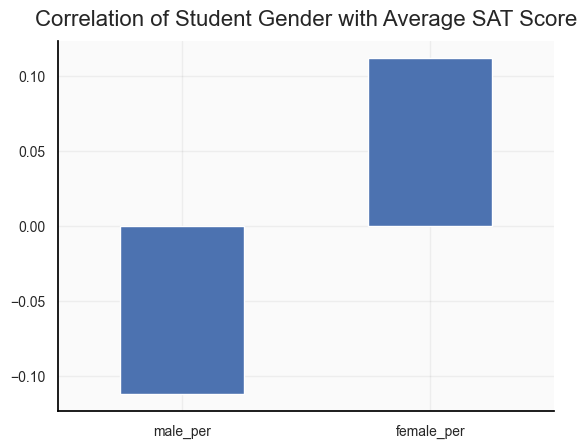

In [62]:
gender_fields = ["male_per", "female_per"]

combined.corr(numeric_only=True)["avg_sat_score"][gender_fields].plot.bar(rot=0)
plt.title("Correlation of Student Gender with Average SAT Score", y=1.02, fontsize=16)

plt.show()

In [63]:
combined.corr(numeric_only=True)["avg_sat_score"][gender_fields]

male_per     -0.112062
female_per    0.112108
Name: avg_sat_score, dtype: float64

We see that a higher population of male students correlates negatively with the average SAT score, whilst the opposite is true of female students. This means schools with a greater female student population will tend to perform better than schools with a greater male student population.

It is important, however, to highlight that the strength of these correlations are **not very strong** (with Pearson correlation coefficients around 0.11 for both relationships).

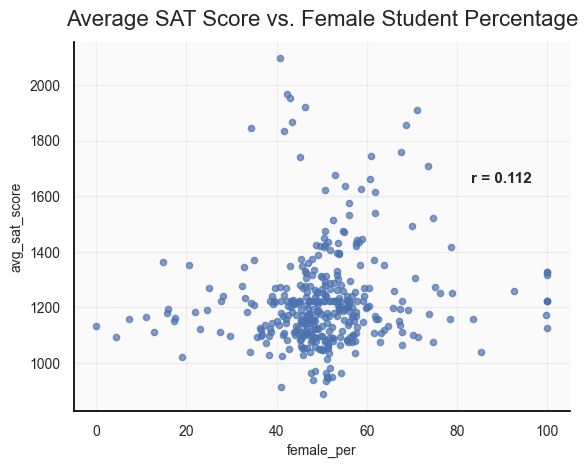

In [64]:
combined.plot.scatter(x="female_per", y="avg_sat_score", alpha=0.7)
plt.title("Average SAT Score vs. Female Student Percentage", y=1.02, fontsize=16)
plt.text(83, 1650, f"r = {combined.corr(numeric_only=True)['avg_sat_score']['female_per']:0.3f}", weight="bold", fontsize=11)

plt.show()

Looking at the visualization, the strength of the linear correlation is clearly poor. There are a cluster of schools that do seem to have a large percentage of female students (between 60 to 80%) with relatively high average SAT scores however.

#### Schools with an Elevated Female Student Population with Good SAT Scores

In [65]:
high_female_high_sat = combined[(combined["female_per"].between(60, 80)) & (combined["avg_sat_score"] > 1600)][["SCHOOL NAME"]]

high_female_high_sat

,SCHOOL NAME
5,BARD HIGH SCHOOL EARLY COLLEGE
26,ELEANOR ROOSEVELT HIGH SCHOOL
27,MILLENNIUM HIGH SCHOOL
60,BEACON HIGH SCHOOL
61,FIORELLO H. LAGUARDIA HIGH SCHOOL OF MUSIC & A...
287,BARD HIGH SCHOOL EARLY COLLEGE II
302,TOWNSEND HARRIS HIGH SCHOOL


Schools in this cluster appear to be highly selective liberal arts schools which have high academic standards (e.g., [Beacon High School](https://insideschools.org/school/03M479)). Since these institutions cater more towards subjects that females traditionally are more interested in (Dance, Drama, Arts *etc.*) and the schools highly value academic performance, we would expect these schools to have a greater female student population **and** for the average SAT scores to be on the higher end.

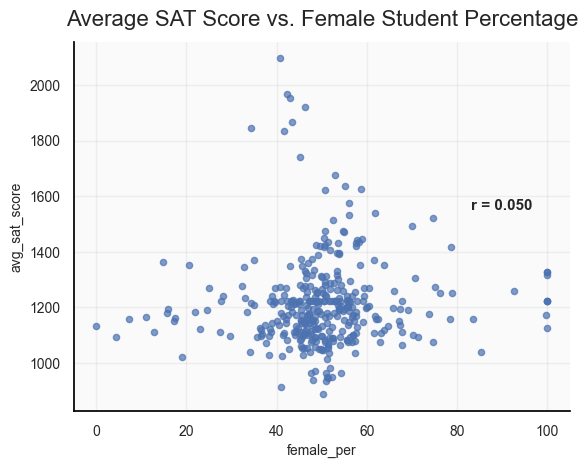

In [66]:
combined_without_high_female_high_sat_cluster = combined.drop(high_female_high_sat.index)

combined_without_high_female_high_sat_cluster.plot.scatter(x="female_per", y="avg_sat_score", alpha=0.7)

plt.title("Average SAT Score vs. Female Student Percentage", y=1.02, fontsize=16)

# show updated correlation without the cluster of schools
plt.text(83, 1550, f"r = {combined_without_high_female_high_sat_cluster.corr(numeric_only=True)['avg_sat_score']['female_per']:0.3f}", weight="bold", fontsize=11)

plt.show()

Dropping the cluster of schools identified above, we see the strength of the correlation significantly drop. This cluster contributed heavily to the correlation between female student percentage and average SAT score. As a result, it becomes less likely the gender of a student influences SAT performance to any noticeable extent.

## AP Exam Scores vs. SAT Exam Scores

We now turn to look at any relationships between AP Exam Scores and SAT Exam scores. We can hypothesise that schools which have a greater number of passing AP scores tend to have an elevated average SAT score. This makes logical sense, since you may predict that students who perform well on subject-specific advanced placement exams are more likely to perform well on a standardized test (and vice versa).

We must be careful when approaching our analysis since `total_enrollment` is highly correlated with `avg_sat_score`. To avoid bias, we can first look at the percentage of students per school who took at least one AP exam. 

This statistic will be saved to a new field: `ap_per`, which is calculated by dividing the number of AP test takers by the total number of students enrolled per school.

#### SAT Scores vs. Percentage of Students who take at least one AP exam

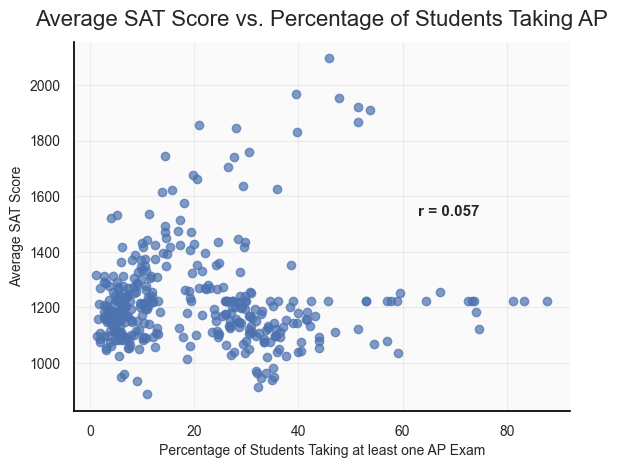

In [67]:
combined["ap_per"] = round((combined["AP Test Takers "] / combined["total_enrollment"]) * 100, 2)

plt.scatter("ap_per", "avg_sat_score", data=combined, alpha=0.7)
plt.title("Average SAT Score vs. Percentage of Students Taking AP", y=1.02, fontsize=16)
plt.text(63, 1530, f"r = {combined.corr(numeric_only=True)['avg_sat_score']['ap_per']:0.3f}", weight="bold", fontsize=11)
plt.xlabel("Percentage of Students Taking at least one AP Exam", fontsize=10)
plt.ylabel("Average SAT Score", fontsize=10)

plt.show()

We see a very weak positive linear correlation. There are many examples of schools where a large proportion of the student body takes AP exams, but the overall school average SAT score is low. This *could* indicate that just because schools offer AP classes, it does not mean the teaching quality is strong. A better measure of success on the AP exam is required (rather than relying on just the percentage of students taking AP exams) to assess the relationship more fully.

Further investigation is warranted:

In [68]:
combined[["Number of Exams with scores 3 4 or 5", "Total Exams Taken", "AP Test Takers ", "ap_per"]].head()

,Number of Exams with scores 3 4 or 5,Total Exams Taken,AP Test Takers,ap_per
0,153.45,197.038462,129.028846,30.58
1,10.00,49.000000,39.000000,9.90
2,153.45,21.000000,19.000000,3.18
3,153.45,197.038462,129.028846,35.16
4,191.00,377.000000,255.000000,15.81


Looking at our available AP data for each school, we notice there are a significant number of values in the `Number of Exams with scores 3 4 or 5` column that have been imputed with the mean value of the column. This was a side-effect of the approach we used to handle the missing values.

To use this field in our analysis, we will need to drop rows with these filled values as they are not reliable.

In [69]:
fill_value = combined["Number of Exams with scores 3 4 or 5"].mean()

# create a boolean array for rows where the value is equal to the mean value used for imputation. np.isclose is used to avoid floating point precision issues
is_equal = np.isclose(combined["Number of Exams with scores 3 4 or 5"].astype(float), fill_value, atol=1e-8, equal_nan=False) 

# create a copy of the DataFrame to avoid modifying the original, dropping rows where the value is equal to the fill value
ap_results = combined.loc[~is_equal].copy()

print("Dropped", is_equal.sum(), "rows")

Dropped 223 rows


In [70]:
ap_results[["Number of Exams with scores 3 4 or 5", "Total Exams Taken", "AP Test Takers ", "ap_per"]].head()

,Number of Exams with scores 3 4 or 5,Total Exams Taken,AP Test Takers,ap_per
1,10.0,49.0,39.0,9.90
4,191.0,377.0,255.0,15.81
11,10.0,117.0,99.0,22.97
13,15.0,37.0,25.0,8.01
21,152.0,298.0,213.0,15.28


We can now derive a new field `ap_pass_rate` which is calculated by dividing the field `Number of Exams with scores 3 4 or 5` by the `Total Exams Taken` field (and then converted to a percentage).

#### SAT Scores vs. AP Exam Pass Rate

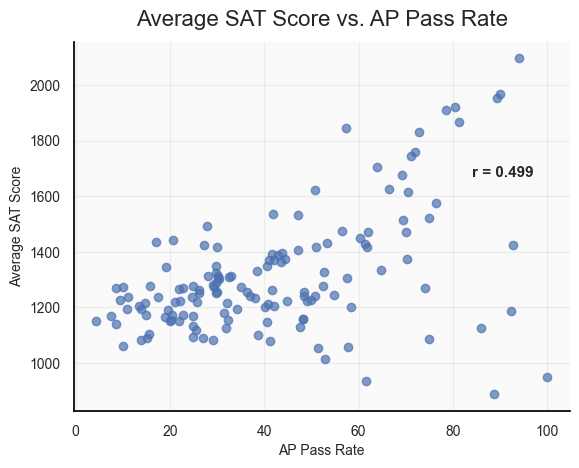

In [71]:
ap_results["ap_pass_rate"] = round((ap_results["Number of Exams with scores 3 4 or 5"] / ap_results["Total Exams Taken"]) * 100, 2)

combined_sat_ap_data = ap_results.copy()

plt.scatter("ap_pass_rate", "avg_sat_score", data=ap_results, alpha=0.7)
plt.title("Average SAT Score vs. AP Pass Rate", y=1.02, fontsize=16)
plt.text(84, 1670, f"r = {ap_results.corr(numeric_only=True)['avg_sat_score']['ap_pass_rate']:0.3f}", weight="bold", fontsize=11)
plt.xlabel("AP Pass Rate", fontsize=10)
plt.ylabel("Average SAT Score", fontsize=10)

plt.show()

Here, we reveal a stronger positive correlation. Typically, schools with a high AP exam pass rate have higher average SAT scores.

There are notable exceptions which will be explored below:

In [72]:
ap_results[(ap_results["ap_pass_rate"] > 80)][["SCHOOL NAME", "total_enrollment", "ap_per", "ap_pass_rate", "avg_sat_score", "Number of Exams with scores 3 4 or 5", "Total Exams Taken"]].sort_values(by="avg_sat_score", ascending=False)

,SCHOOL NAME,total_enrollment,ap_per,ap_pass_rate,avg_sat_score,Number of Exams with scores 3 4 or 5,Total Exams Taken
37,STUYVESANT HIGH SCHOOL,3297,45.80,93.93,2096.0,2648.0,2819.0
151,BRONX HIGH SCHOOL OF SCIENCE,3013,39.50,89.90,1969.0,2189.0,2435.0
356,STATEN ISLAND TECHNICAL HIGH SCHOOL,1104,47.83,89.39,1953.0,809.0,905.0
155,HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE,377,51.46,80.46,1920.0,243.0,302.0
327,QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...,418,51.44,81.36,1868.0,275.0,338.0
46,HIGH SCHOOL FOR DUAL LANGUAGE AND ASIAN STUDIES,353,17.28,92.71,1424.0,89.0,96.0
96,FOREIGN LANGUAGE ACADEMY OF GLOBAL STUDIES,311,4.18,92.31,1186.0,12.0,13.0
344,NEWCOMERS HIGH SCHOOL,932,12.77,85.89,1127.0,140.0,163.0
125,ACADEMY FOR LANGUAGE AND TECHNOLOGY,336,5.95,100.00,951.0,20.0,20.0
253,MULTICULTURAL HIGH SCHOOL,406,10.84,88.64,887.0,39.0,44.0


Looking more closely at schools with an `ap_pass_rate` exceeding 80%, we can identify two clusters - those with average SAT scores greater than 1,800 and those significantly below this (887, 1,127 and 1,424).

* We see schools that do not follow the trend identified in the scatterplot having a considerably lower percentage of students taking AP exams. 

Therefore, we can conclude that schools that have **both** a high `ap_pass_rate` and a significant percentage of students taking AP exams (`ap_per` around 40% and above) are far more likely to have high average SAT scores.

To verify this, we can filter out schools with a relatively low number of students taking AP exams (say `ap_per` less than 20%).

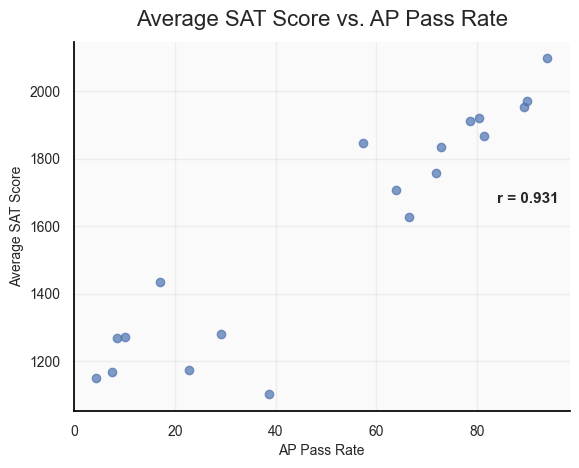

In [73]:
ap_results = ap_results[ap_results["ap_per"] >= 20]

plt.scatter("ap_pass_rate", "avg_sat_score", data=ap_results, alpha=0.7)
plt.title("Average SAT Score vs. AP Pass Rate", y=1.02, fontsize=16)
plt.text(84, 1670, f"r = {ap_results.corr(numeric_only=True)['avg_sat_score']['ap_pass_rate']:0.3f}", weight="bold", fontsize=11)
plt.xlabel("AP Pass Rate", fontsize=10)
plt.ylabel("Average SAT Score", fontsize=10)

plt.show()

Indeed, we see a significant increase in the strength of the positive correlation, supporting the claim that schools where many students take AP exams and have high AP pass rates tend to have high average SAT scores.

This supports the rationale shared by many teachers and professors that the SAT can be used as a predictor of academic success.

## Creating a Ranking System to Evaluate NYC High-School Quality

To assess the quality of a school, we propose creating a ranking system to evaluate a school. The following factors can be used to design a simple ranking system:

>* School Average SAT Score
>
>* School AP Pass Rate
>
>* Percentage of Students taking at least one AP Exam 
>
>* Student Safety Survey Rating
>
>* Student Academic Quality Survey Rating

By taking the four factors above into account, we can design a metric which weights each of these factors and combines them into a single number which can be sorted to rank the schools. The student safety and academic quality rating fields are deemed most relevant as our previous analysis determined the student responses had the most meaningful relationships with the average SAT score. We also want to ensure the school is considered safe rather than only considering academic factors.

This is by no means the only or best approach to generate a ranking-system and it certaintly does not cover all possible contributing factors to what makes a good school. For an initial investigation and preliminary means to rank schools however, the approach is competent and achieves the aim of a ranking system.

In [74]:
school_ranking = combined_sat_ap_data[["SCHOOL NAME", "boro", "school_dist", "lon", "lat", "avg_sat_score", "ap_pass_rate", "ap_per", "saf_s_11", "aca_s_11"]].sort_values(by="avg_sat_score", ascending=False)

school_ranking["rank_score"] = 1.2*school_ranking["avg_sat_score"] * (1.5*(school_ranking["saf_s_11"] + school_ranking["aca_s_11"]) + (school_ranking["ap_per"] / 100)*school_ranking["ap_pass_rate"])

school_ranking.head()

,SCHOOL NAME,boro,school_dist,lon,lat,avg_sat_score,ap_pass_rate,ap_per,saf_s_11,aca_s_11,rank_score
37,STUYVESANT HIGH SCHOOL,Manhattan,02,-74.014049,40.717746,2096.0,93.93,45.80,7.5,7.9,166304.873088
151,BRONX HIGH SCHOOL OF SCIENCE,Bronx,10,-73.889780,40.877056,1969.0,89.90,39.50,6.8,7.6,134940.689400
356,STATEN ISLAND TECHNICAL HIGH SCHOOL,Staten Island,31,-74.115362,40.567913,1953.0,89.39,47.83,8.2,8.5,158908.353433
155,HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE,Bronx,10,-73.897516,40.871255,1920.0,80.46,51.46,8.1,8.6,153111.665664
302,TOWNSEND HARRIS HIGH SCHOOL,Queens,25,-73.821417,40.734408,1910.0,78.52,53.77,7.8,8.1,151432.907568


To create the `rank_score`: 

1)  The average SAT score is used as a basline value (multipled by a weighting factor of 1.2). 

2)  The combined sum of the two student survey fields are multiplied by a factor of 1.5 (increasing the weight of these factors when combined into the overall score) and the *product* of the School AP pass rate and proportion of the student body who take at least one AP exam is then added to the result. The proportion of students taking at least one AP exam is important to weight the overall rank score, since it makes sense to reward schools with **many** students taking and passing AP exams rather than schools that have few students taking AP exams.

3)  Finally, the baseline value is multipled by the result of step two to yield the `rank_score`.

---
## Standardizing the Distribution of Rank Scores

In order to give the meaningless `rank_score` values some meaning, we standardize the distribution by:

>1) Calculating the z-score for each `rank_score` in the distribution.
>
>2) Transforming the distribution of z-scores into a distribution with a mean value of two and a standard deviation of one.

This creates rank_score values which are much more managable (numbers between 0 and 6) and provide some indication of quality. For instance, a school with a rank_score of 4 would lie 2 standard deviations **above** the mean of 2. Assuming a normal distribution, this would mean the school would lie in the **95th percentile (i.e., Top 5%)** in the ranking system.

This process is completed below:

In [75]:
# calculate z-scores for the rank_score field. Since we are using a sample, Bessel's correction is applied by setting ddof=1
rank_z_scores = round((school_ranking["rank_score"] - school_ranking["rank_score"].mean()) / school_ranking["rank_score"].std(ddof=1), 2)

school_ranking["rank_z_score"] = rank_z_scores

school_ranking["rank_score"] = round(school_ranking["rank_z_score"].apply(lambda x: 2 + x*1), 2) # convert z-scores to a score with mean of 2 and stddev of 1

school_ranking = school_ranking.sort_values(by="rank_score", ascending=False) 

school_ranking["saf_s_11"] = school_ranking["saf_s_11"].round(2) # round safety and academic scores to two decimal places
school_ranking["aca_s_11"] = school_ranking["aca_s_11"].round(2)

#### Visualizing the Distribution of School Rank Scores

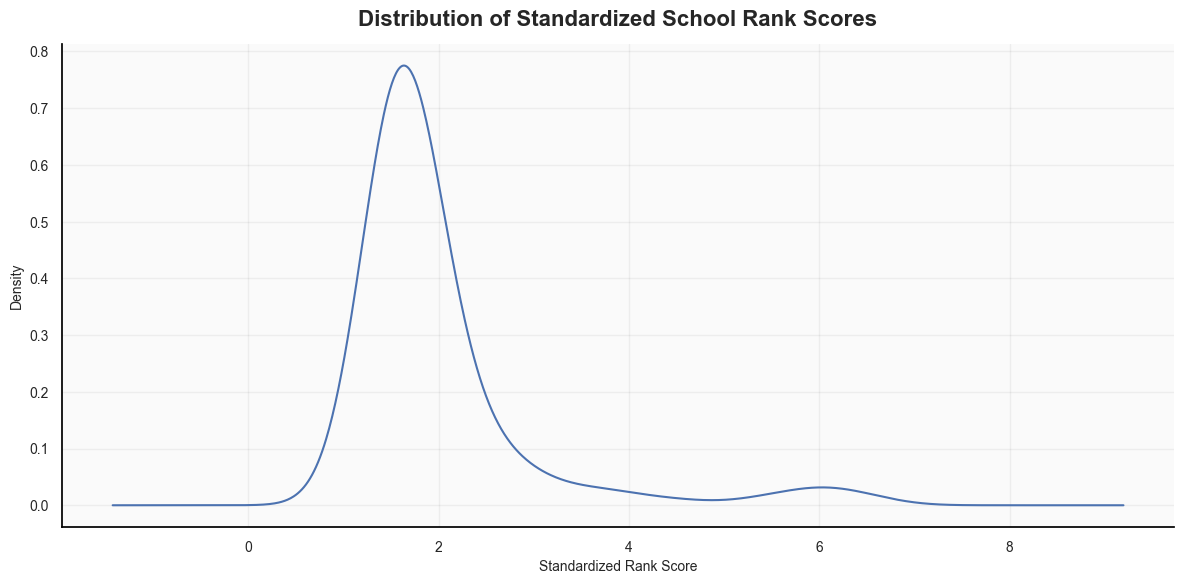

In [76]:
school_ranking.plot.kde(y="rank_score", figsize=(12,6))
plt.title("Distribution of Standardized School Rank Scores", y=1.02, fontsize=16, weight="bold")
plt.xlabel("Standardized Rank Score", fontsize=10)

plt.legend().remove()
plt.tight_layout()
plt.show()

The Kernel Density Estimate plot above shows the distribution of ranks generated by the ranking system is roughly normal. Some positive skew is apparent, which indicates there are a small number of extreme values on the higher end of the rank score distribution (the "elite" NYC high schools in our sample that lie far from the mean rank score of the sample). This can be spotted in the plot from the peak observed at standardized rank score 6.

The main takeaway is the rough normally distributed nature of the rank score distribution. This allows us to *estimate* the percentile that each school falls within (using the [68-95-99.7 rule](https://en.wikipedia.org/wiki/68–95–99.7_rule) of normal distributions). This is an **empirical rule** which states observations within one standard deviation of the mean comprise of 68% of the total datapoints. Those which lie within two standard deviations comprise of 95% of the total datapoints, whilst those lying within three standard deviations comprise of 99.7% of the total datapoints. 

Clearly, we are not handling a perfect normal distribution, so this rule will only serve as an estimate for the percentile rank of each school.

---

#### Adding a Rank Level Field

A `rank_level` field is also created, binning the rank scores into six categories. This is done to produce a column to indicate a rough percentile rank for the schools in the distribution. To determine the bin intervals, an [inverse normal distribution calculator](https://onlinestatbook.com/2/calculators/inverse_normal_dist.html) was used.

For example, for a school to lie in the `Top 10%`, it must have a rank score greater than 3.28 but less than 4.32. The 3.28 boundary was determined using the inverse normal distribution calculator which, for a normal distribution with a mean of 2 and standard deviation of 1, is the value that when exceeded, gives the datapoint a less than 10% probability of occurring.

*Note,* we are not handling a perfect normal distribution here, so this system just serves as an estimate. It is sufficient to provide a meaningful classification system for NYC High Schools as detailed below:

In [77]:
# bin the rank_score into 6 levels and label them. the bin boundaries were calculated using an inverse normal distribution calculator to give a rough estimate of the percentile rank for each school
school_ranking["rank_level"] = pd.cut(school_ranking["rank_score"], [0.72, 1.75, 2, 2.25, 3.28, 4.32, 6.55], labels=["Requires Attention", "Some Support", "Satisfactory", "Good", "Excellent", "Outstanding"], include_lowest=True)

In [78]:
school_ranking[["SCHOOL NAME", "boro", "school_dist", "avg_sat_score", "ap_per", "ap_pass_rate", "saf_s_11", "aca_s_11", "rank_score", "rank_z_score", "rank_level"]]

,SCHOOL NAME,boro,school_dist,avg_sat_score,ap_per,ap_pass_rate,saf_s_11,aca_s_11,rank_score,rank_z_score,rank_level
37,STUYVESANT HIGH SCHOOL,Manhattan,02,2096.0,45.80,93.93,7.50,7.90,6.54,4.54,Outstanding
356,STATEN ISLAND TECHNICAL HIGH SCHOOL,Staten Island,31,1953.0,47.83,89.39,8.20,8.50,6.26,4.26,Outstanding
155,HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE,Bronx,10,1920.0,51.46,80.46,8.10,8.60,6.04,4.04,Outstanding
302,TOWNSEND HARRIS HIGH SCHOOL,Queens,25,1910.0,53.77,78.52,7.80,8.10,5.98,3.98,Outstanding
327,QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...,Queens,28,1868.0,51.44,81.36,7.20,7.90,5.72,3.72,Outstanding
151,BRONX HIGH SCHOOL OF SCIENCE,Bronx,10,1969.0,39.50,89.90,6.80,7.60,5.36,3.36,Outstanding
187,BROOKLYN TECHNICAL HIGH SCHOOL,Brooklyn,13,1833.0,39.70,72.78,7.00,7.60,4.49,2.49,Outstanding
26,ELEANOR ROOSEVELT HIGH SCHOOL,Manhattan,02,1758.0,30.57,71.91,8.10,8.20,3.98,1.98,Excellent
278,LEON M. GOLDSTEIN HIGH SCHOOL FOR THE SCIENCES,Brooklyn,22,1627.0,35.91,66.43,7.60,7.60,3.72,1.72,Excellent
79,"HIGH SCHOOL FOR MATHEMATICS, SCIENCE AND ENGIN...",Manhattan,05,1847.0,28.08,57.26,7.80,8.20,3.64,1.64,Excellent


In [79]:
print(f"'combined' dataframe sample size: {combined.shape[0]}")
print(f"'school_ranking' dataframe sample size: {school_ranking.shape[0]}")

'combined' dataframe sample size: 363
'school_ranking' dataframe sample size: 140


In [80]:
print(f"Average Student Safety Score: {school_ranking['saf_s_11'].mean():0.2f}")
print(f"Average Student Academic Score: {school_ranking['aca_s_11'].mean():0.2f}")

Average Student Safety Score: 6.66
Average Student Academic Score: 7.39


In [81]:
school_ranking["rank_level"].value_counts().sort_index()

rank_level
Requires Attention    84
Some Support          25
Satisfactory           8
Good                  12
Excellent              4
Outstanding            7
Name: count, dtype: int64

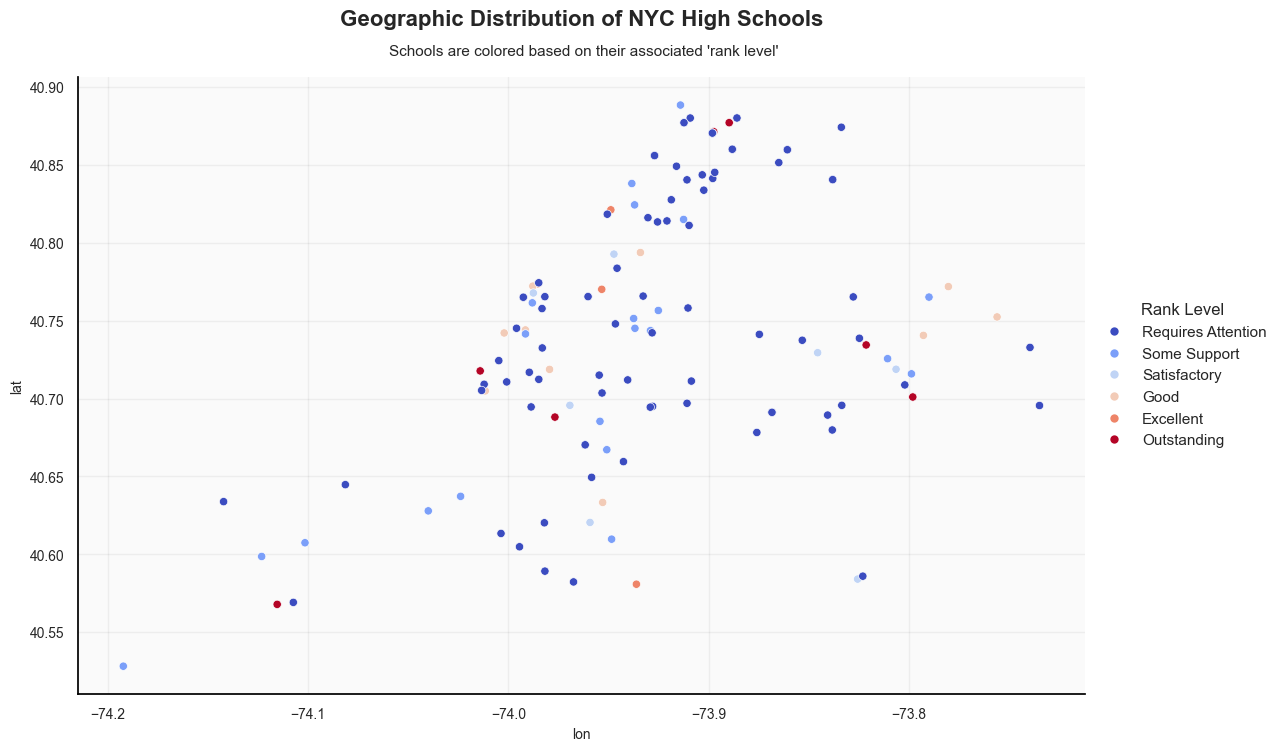

In [82]:
import matplotlib as mpl

cmap = mpl.colormaps["coolwarm"] # get the "coolwarm" colormap from Matplotlib
palette = [mpl.colors.to_hex(cmap(x)) for x in np.linspace(0, 1, 6)] # create a list of 6 colors from the colormap

rank_plot = sns.relplot(data=school_ranking,
            x="lon",
            y="lat", 
            hue="rank_level",
            palette=palette, 
            height=7,  # height of figure (inches)
            aspect=1.6, # width/height ratio
            )

plt.title("Geographic Distribution of NYC High Schools", y=1.07, fontsize=16, weight="bold")
plt.text(-74.0596, 40.92,"Schools are colored based on their associated 'rank level'", fontsize=11)

rank_plot._legend.set_title("Rank Level") # set legend title to "Rank Level"

plt.savefig("nyc_high_schools_ranked_map.svg")
plt.show()

#### Remarks

First, it is important to note that the number of schools with all of the required data for the ranking system was only 140. 223 schools did not have the required AP Exam Result data to rank. This means the resulting rankings do not provide a full picture of the entire population of NYC high schools, though useful information can still be gathered from the schools that could be ranked (and will likely be representative of the population as a whole).

The sample of 140 schools reveal that the majority of high schools in the city (84) require improvement. This is a result of how the rank score is determined of course, so the criteria could be made harsher or more lenient depending on how each of the factors is weighted when calculating the rank score for each school. This is not something that will be modified further here, but is necessary to refine the ranking system. This would be of relevance for the New York City council to monitor progress and allocate support for struggling schools.

For the weights used above, the school with the greatest rank score that falls into the "Requires Attention" category is shown below. This school lies 0.26 standard deviations below the mean rank score:

In [83]:
school_ranking[school_ranking["SCHOOL NAME"] == "HIGH SCHOOL FOR ARTS AND BUSINESS"][["SCHOOL NAME", "boro", "school_dist", "avg_sat_score", "ap_per", "ap_pass_rate", "saf_s_11", "aca_s_11", "rank_score", "rank_z_score", "rank_level"]]

,SCHOOL NAME,boro,school_dist,avg_sat_score,ap_per,ap_pass_rate,saf_s_11,aca_s_11,rank_score,rank_z_score,rank_level
292,HIGH SCHOOL FOR ARTS AND BUSINESS,Queens,24,1174.0,23.91,22.81,7.0,7.4,1.74,-0.26,Requires Attention


Looking at [nation-wide average SAT scores](https://blog.collegevine.com/new-sat-vs-old-sat-score-conversion-chart#conversion), the average score is typically around the region of 1,450-1,500 (when converted from the newer 1,600 total score SAT exam). For the above school, an average SAT score of 1,174 is far off target, which supports the "Requires Attention" level it has received in the ranking system.

The 2010 Annual [AP Report to the Nation](https://secure-media.collegeboard.org/digitalServices/pdf/research/7th-annual-ap-report-to-the-nation.pdf) details that in the State of New York, the state-wide AP pass rate was 63.1% (the sum of all exams with a 3, 4 or 5 grade). Again, looking at the AP pass rate field of the above school, 22.81% falls significantly short of the state-wide average which also supports the "Requires Attention" category.

The safety score as assessed by the students is slightly above average which is good, though the academic score is about average. Overall, the contribution of the poor average SAT score and AP pass rate has contributed to this school being categorised as requiring attention.

>Although this ranking system is simplistic, is does consider multiple factors when assessing the final rank score and does enable a relatively competent categorisation system to assist in supporting schools. As mentioned previously, the system would need refining and tailored to the NYC council's preferences, but this preliminary work demonstrates the feasibility of the approach in assessing school quality in NYC.

---

With regard to the geographic distribution of schools, although only a sample of 140 high schools could be used, we obtain a relatively informative map of school quality across the city. We must be careful not to make sweeping conclusions here however, as only a portion of the total high schools across the city had sufficient data for these ranks to be determined. 

Some simple observations:

* It appears that the Manhattan borough has a high number of institutions with favorable rank scores. 

* There is at least one school in each borough that is categorised as Excellent or Outstanding.

* Unfortunately, many schools do suffer from average SAT scores and AP results that are lower than the national average. These schools are typically spread throughout all boroughs, but are particularly concentrated in the built-up areas of the Bronx and Manhattan. 

## Conclusion

Using publically available data from the New York City Open Data initiative, a number of interesting relationships and observations have been made regarding factors that contribute to a US High School's average SAT exam performance. 

Before outlining some of the key findings, it is important to consider the sample used to generate these conclusions. Relationships with socio-economic and demographic factors where determined using a sample size of 363 high schools across the entire city. This is a fairly sizeable sample size and is likely to be representative of the NYC High School population as a whole since the sample covers schools from all districts.

To assess relationships between average SAT score and AP exam performance (and devise the school ranking system), the sample size fell to 140 high schools as the remaining 223 did not have sufficient AP result data:

* With regard to the strength of the correlation observed between AP pass rate and average SAT score, it is highly likely that this is a true representation of the relationship across the entire population desptie the hit to the sample size. This is primarily due to the strength of the Pearson correlation coefficient from the sample of 140 high schools (which comes in at 0.93 when accounting for the percentage of the student body which takes AP exams). The 140 high school sample, although smaller, is still sufficiently large and still contains schools based all across the districts and boroughs of the city.

* Turning to the devised ranking system, a reduction in sample size down to 140 certainly reduces the applicability of the ranking system as many schools have been omitted from the ranks. If all other schools could be included, the distribution of rank scores for the schools would be expected to change and many which are considered to be poor performers in the current 140 schools may be seen more favourably if many other schools are in a worse state. If this ranking system was to be developed further, obtaining AP Exam result data for all other high schools in the city would be critical to better assess the complete landscape.

### Key Findings

>* A school's `total_enrollment` has a positive correlation (0.37) with average SAT score, which *suggests* larger schools tend to perform better on the SAT. This trend is shared across other proxies for enrollment (`total_students`, `N_s`, `N_p`, `N_t`, `AP Test Takers`, `Total Exams Taken`, `NUMBER OF SECTIONS`, `Average Class Size` *etc.*). Delving into this observation, it seems likely that schools with a greater number of enrolled students are most likely to be well funded, with better standards of teaching. This is likely the cause of the observed correlation, rather than simply more enrolled students leading to better average SAT scores.
>
>* Although there was evidence of a weak relationship between gender and average SAT score (where schools with a greater percentage of female students tending to have higher SAT scores), it was found that the strength of the correlation was somewhat enhanced by the presence of selective liberal arts schools with high academic standards. Removing these from the dataset led to a drastic weakening of the linear relationship between gender and average SAT score, suggesting there is little evidence to support a significant difference between males and females on the SAT.
>
>* Teacher and student ratings of school safety (`saf_s_11` and `saf_t_11`) were found to correlate positively with SAT scores, highlighting the importance of **safe** environments to deliver higher quality education.
>
>* Student ratings of school academic standards (`aca_s_11`) correlate positively with SAT scores, but the strength of this relationship does *not* hold to the same extent for teacher and parent ratings (`aca_t_11` and `aca_p_11`). This may suggest students themselves have the best judgement of a school's teaching ability rather than teachers or parents/guardians (who are less involved with the full education process that a student will be exposed to).
>
>* There seems to be significant racial inequality in SAT scores. Student bodies with a higher proportion of hispanic and black students were found to have lower average SAT scores than schools with fewer students from these backgrounds. No cause could be directly determined from this analysis alone, but we can speculate that wider systemic issues contribute to this. Historically, the hispanic and black community are more under-priveledged than members of the white and asian community. Over the course of history, this has had a significant impact on members of these under-priveledged communties, harming their social status (through racism/predjudice), wealth and access to resources.
>
>* The percentage of students eligible for free/reduced-cost school lunch based on household income (`frl_percent`) has a negative correlation with SAT scores. This supports the idea that students who face challenges such as poverty or low household income are pre-disposed to difficulties in their educational lives. Again, no direct cause could be determined, but we can comfortably speculate that challenges and unrest in a student's home life are likely to harm the ability of that student to focus on their education (hence the poorer performance on the SAT for many of these students).
>
>* Schools with increased levels of English language learners typically perform worse on the SAT. This can be explained by the presence of two English Language sections on the SAT, contributing to two-thirds of the total score. It was observed that schools with an ELL percentage exceeding 80% often perform poorly on the SAT (with average SAT scores less than 1,000). This is probably the area where the SAT struggles the most when trying to give students from ***all** backgrounds an equal chance at success.
>
>* Geographic locations of schools were used to i) uncover districts in the city that cater to newly English speaking immigrant communities, and, ii) indicate more dangerous districts through use of school safety ratings as determined by survey results.
>
>* Finally, a strong linear relationship (Pearson r ~ 0.93) between average SAT score and AP exam pass rate was established. It was found that schools with a combination of **both** a high percentage of passing AP exam grades and a relatively high proportion of students taking at least one SAT exam typically had strong average SAT exam scores. This firmly supports the idea that the SAT can be viewed as a good predictor of academic success.